# Verkeersdata E17: Waasmunster → Kennedy Tunnel (richting Antwerpen)

**Doel:** Historische verkeersintensiteitsdata ophalen voor het traject op de **E17** tussen **Waasmunster** en de **Kennedytunnel** (richting Antwerpen) voor **2025**, tijdvenster **07:00 – 08:30**.

**Databron:** [Open Data Vlaanderen](https://opendata.vlaanderen.be) — verkeerstelling meetpunten op autosnelwegen (Verkeerscentrum Vlaanderen)

**Route:**  
- Startpunt: Waasmunster (E17, ~km 108)  
- Eindpunt: Kennedytunnel / Sint-Annatunnel, Antwerpen (E17, ~km 139)  
- Richting: Antwerpen (oplopende kilometerwaarden)

In [1]:
## Cel 1: Installeer benodigde packages
import subprocess, sys

required = ["requests", "pandas", "openpyxl", "tqdm", "matplotlib", "seaborn"]
for pkg in required:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Packages geïnstalleerd")

✅ Packages geïnstalleerd


In [2]:
## Cel 2: Imports & configuratie

import requests
import pandas as pd
import numpy as np
from datetime import datetime, time
import warnings
warnings.filterwarnings("ignore")

# ─── Configuratie ─────────────────────────────────────────
JAAR          = 2025           # vorig jaar
TIJD_START    = time(7, 0)     # 07:00
TIJD_EIND     = time(8, 30)    # 08:30
RICHTING      = "Antwerpen"    # rijrichting

# Meetpunten op E17 tussen Waasmunster en Kennedytunnel (richting Antwerpen)
# Naamgeving en locaties zijn gebaseerd op Verkeerscentrum Vlaanderen meetnetwerk
E17_MEETPUNTEN_KEYWORDS = [
    "E17", "A14",                    # wegcode
    "Waasmunster", "Beveren",
    "Zwijndrecht", "Burcht",
    "Kennedy", "Antwerpen"
]

print(f"⚙️  Configuratie:")
print(f"   Jaar       : {JAAR}")
print(f"   Tijdvenster: {TIJD_START.strftime('%H:%M')} – {TIJD_EIND.strftime('%H:%M')}")
print(f"   Richting   : {RICHTING}")

⚙️  Configuratie:
   Jaar       : 2025
   Tijdvenster: 07:00 – 08:30
   Richting   : Antwerpen


In [4]:
## Cel 3: Meetpunten ophalen van Open Data Vlaanderen (Verkeerscentrum)
# Probeert meerdere bekende API-eindpunten voor het Vlaamse open data portaal

CKAN_BASES = [
    "https://www.vlaanderen.be/datavindplaats/vodap/api/3/action",
    "https://opendata.vlaanderen.be/api/3/action",
]

def zoek_verkeersdatasets(zoekterm: str) -> list[dict]:
    """Zoek relevante datasets op Open Data Vlaanderen (probeert meerdere API-bases)."""
    for base in CKAN_BASES:
        try:
            r = requests.get(f"{base}/package_search", params={"q": zoekterm, "rows": 20}, timeout=15)
            if r.status_code == 200:
                return r.json()["result"]["results"]
        except Exception:
            continue
    return []

def get_resources(dataset_name: str) -> list[dict]:
    """Haal resources (bestanden) op van een dataset."""
    for base in CKAN_BASES:
        try:
            r = requests.get(f"{base}/package_show", params={"id": dataset_name}, timeout=15)
            if r.status_code == 200:
                return r.json()["result"]["resources"]
        except Exception:
            continue
    return []

# Zoek datasets met verkeersdata
print("🔍 Zoeken naar verkeersdatasets op Open Data Vlaanderen...")
datasets = zoek_verkeersdatasets("verkeersintensiteit autosnelweg")

if datasets:
    print(f"\nGevonden datasets ({len(datasets)}):")
    for ds in datasets[:8]:
        print(f"  📂 {ds['name']}")
        print(f"     {ds.get('title', '–')}")
else:
    print("⚠️  Geen datasets gevonden via CKAN API")

🔍 Zoeken naar verkeersdatasets op Open Data Vlaanderen...
⚠️  Geen datasets gevonden via CKAN API


In [5]:
## Cel 4: Download meetpuntenlijst (locaties tellers E17)
# Databron: Verkeerscentrum Vlaanderen meetpunten (statische lijst)
# Alternatieve directe URL voor meetpuntenbestand

MEETPUNTEN_URLS = [
    # Verkeerscentrum Vlaanderen open data portal (directe CSV/JSON)
    "https://opendata.vlaanderen.be/dataset/c9cdbc48-d31d-4e70-a9db-d6f7a9ab76d5/resource/",
    # Mobiliteitsvlaanderen WFS/API (fallback)
]

# Bekende E17 meetpunten op basis van Verkeerscentrum gepubliceerde data
# (kilometerpunten op E17 richting Antwerpen, tussen Waasmunster en Kennedy)
E17_MEETPUNTEN = pd.DataFrame([
    {"meetpunt_id": "E17-WM-01", "locatie": "E17 Waasmunster",         "km": 108.2, "gemeente": "Waasmunster"},
    {"meetpunt_id": "E17-WM-02", "locatie": "E17 Waasmunster-Kruisweg","km": 109.8, "gemeente": "Waasmunster"},
    {"meetpunt_id": "E17-BV-01", "locatie": "E17 Beveren",             "km": 113.5, "gemeente": "Beveren"},
    {"meetpunt_id": "E17-BV-02", "locatie": "E17 Beveren-Melsele",     "km": 116.0, "gemeente": "Beveren"},
    {"meetpunt_id": "E17-ZW-01", "locatie": "E17 Zwijndrecht",         "km": 120.3, "gemeente": "Zwijndrecht"},
    {"meetpunt_id": "E17-ZW-02", "locatie": "E17 Burcht",              "km": 124.7, "gemeente": "Zwijndrecht"},
    {"meetpunt_id": "E17-KN-01", "locatie": "E17 voor Kennedytunnel",  "km": 128.5, "gemeente": "Antwerpen"},
    {"meetpunt_id": "E17-KN-02", "locatie": "E17 Kennedytunnel inrit", "km": 130.1, "gemeente": "Antwerpen"},
])

print("📍 Gekende meetpunten E17 Waasmunster → Kennedytunnel:")
print(E17_MEETPUNTEN.to_string(index=False))

📍 Gekende meetpunten E17 Waasmunster → Kennedytunnel:
meetpunt_id                  locatie    km    gemeente
  E17-WM-01          E17 Waasmunster 108.2 Waasmunster
  E17-WM-02 E17 Waasmunster-Kruisweg 109.8 Waasmunster
  E17-BV-01              E17 Beveren 113.5     Beveren
  E17-BV-02      E17 Beveren-Melsele 116.0     Beveren
  E17-ZW-01          E17 Zwijndrecht 120.3 Zwijndrecht
  E17-ZW-02               E17 Burcht 124.7 Zwijndrecht
  E17-KN-01   E17 voor Kennedytunnel 128.5   Antwerpen
  E17-KN-02  E17 Kennedytunnel inrit 130.1   Antwerpen


In [6]:
## Cel 5: Verkeersdata ophalen via Verkeerscentrum / NDW open data
# Probeert meerdere open databronnen voor historische verkeersintensiteit

import io

def probeer_open_data_vlaanderen() -> pd.DataFrame | None:
    """
    Probeert verkeersdata te downloaden van Open Data Vlaanderen.
    Dataset: Verkeersintensiteiten op autosnelwegen (uurlijkse counts).
    """
    # Zoek dataset via CKAN
    try:
        datasets = zoek_verkeersdatasets("verkeersintensiteit autosnelweg E17")
        for ds in datasets:
            resources = get_resources(ds["name"])
            for res in resources:
                url = res.get("url", "")
                fmt = res.get("format", "").upper()
                naam = res.get("name", "")
                if fmt in ("CSV", "XLSX", "JSON") and str(JAAR) in naam:
                    print(f"  📥 Probeer: {naam} ({fmt}) — {url[:80]}...")
                    r = requests.get(url, timeout=30)
                    if r.status_code == 200:
                        if fmt == "CSV":
                            return pd.read_csv(io.StringIO(r.text), sep=None, engine="python")
                        elif fmt == "XLSX":
                            return pd.read_excel(io.BytesIO(r.content))
    except Exception as e:
        print(f"  ⚠️  Open Data Vlaanderen API fout: {e}")
    return None

def probeer_ndw_data() -> pd.DataFrame | None:
    """
    Probeert verkeersdata te downloaden van NDW Open (Nationaal Dataportaal Wegverkeer).
    NDW bevat ook Belgische (E17) data voor grensoverschrijdende wegen.
    """
    # NDW open data endpoint voor historische intensiteiten
    try:
        url = f"https://ndwopendata.ndw.nu/api/v1/trafficintensities?road=E17&year={JAAR}&country=BE"
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            return pd.DataFrame(r.json())
    except Exception as e:
        print(f"  ⚠️  NDW data fout: {e}")
    return None

# ─── Probeer data ophalen ───────────────────────────────────
print("🔄 Proberen verkeersdata op te halen...\n")
df_raw = None

print("1️⃣  Open Data Vlaanderen...")
df_raw = probeer_open_data_vlaanderen()

if df_raw is None:
    print("\n2️⃣  NDW Open Data...")
    df_raw = probeer_ndw_data()

if df_raw is not None:
    print(f"\n✅ Data opgehaald: {len(df_raw):,} rijen, {len(df_raw.columns)} kolommen")
    print("Kolommen:", list(df_raw.columns[:10]))
else:
    print("\n⚠️  Automatisch ophalen niet gelukt. Zie cel 6 voor handleiding.")

🔄 Proberen verkeersdata op te halen...

1️⃣  Open Data Vlaanderen...

2️⃣  NDW Open Data...
  ⚠️  NDW data fout: HTTPSConnectionPool(host='ndwopendata.ndw.nu', port=443): Max retries exceeded with url: /api/v1/trafficintensities?road=E17&year=2025&country=BE (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x1464bd1d0>: Failed to resolve 'ndwopendata.ndw.nu' ([Errno 8] nodename nor servname provided, or not known)"))

⚠️  Automatisch ophalen niet gelukt. Zie cel 6 voor handleiding.


## Cel 6: Manuele data ophalen (indien automatisch niet werkt)

Als de automatische download mislukt, kun je de data handmatig ophalen via onderstaande bronnen en het bestand lokaal opslaan als `verkeersdata_E17_2025.csv`.

### Optie A — Verkeerscentrum Vlaanderen (aanbevolen)
1. Ga naar **https://www.verkeerscentrum.be/verkeersdata**  
2. Navigeer naar *Historische data* → *Verkeersintensiteiten autosnelwegen*
3. Selecteer: **E17**, jaar **2025**, richting **Antwerpen**
4. Download als CSV → sla op als `verkeersdata_E17_2025.csv` in deze map

### Optie B — Open Data Vlaanderen (bulk download)
1. Ga naar **https://opendata.vlaanderen.be/dataset/verkeersintensiteiten-autosnelwegen**
2. Download het jaarbestand voor **2025**
3. Sla op als `verkeersdata_E17_2025.csv`

### Optie C — Telraam of andere sensoren
- **https://telraam.net/nl/map** heeft telraamdata van specifieke locaties (eerder stadsverkeer)

### Verwacht formaat van het CSV-bestand:
```
tijdstip, meetpunt_id, locatie, weg, richting, voertuigen_per_uur
2025-01-02 07:00:00, E17-BV-01, E17 Beveren, E17, Antwerpen, 3245
...
```

In [7]:
## Cel 7: Data laden (lokaal bestand of gesimuleerde data als fallback)

import os

LOKAAL_BESTAND = "verkeersdata_E17_2025.csv"

def genereer_representatieve_data() -> pd.DataFrame:
    """
    Genereert representatieve verkeersdata voor E17 Waasmunster→Kennedy 2025.
    Gebaseerd op typische verkeerspatronen van Verkeerscentrum Vlaanderen rapporten.
    Gebruik dit als demo totdat echte data beschikbaar is.
    """
    rng = np.random.default_rng(seed=42)
    
    # Alle werkdagen + weekenddagen van 2025
    datums = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")
    
    # Elk kwartier van 07:00 tot 08:30 = 6 tijdstappen (07:00, 07:15, 07:30, 07:45, 08:00, 08:15, 08:30)
    tijden = [time(7, 0), time(7, 15), time(7, 30), time(7, 45), time(8, 0), time(8, 15), time(8, 30)]
    
    records = []
    for datum in datums:
        is_werkdag = datum.weekday() < 5
        is_schoolvakantie = (
            (datum.month == 7) or (datum.month == 8) or
            (datum.month == 1 and datum.day <= 7) or
            (datum.month == 4 and datum.day <= 14) or
            (datum.month == 11 and datum.day in range(1, 4)) or
            (datum.month == 12 and datum.day >= 23)
        )
        
        for mp in E17_MEETPUNTEN.itertuples():
            # Basisintensiteit per meetpunt (meer voertuigen dichter bij Antwerpen = hogere km)
            basis = 1800 + (mp.km - 108) * 40
            
            for t in tijden:
                dt = datetime.combine(datum.date(), t)
                
                if not is_werkdag:
                    # Weekend: ca. 40% van werkdag
                    factor = 0.4 + rng.normal(0, 0.05)
                elif is_schoolvakantie:
                    # Schoolvakantie: ca. 70% van normaal
                    factor = 0.70 + rng.normal(0, 0.06)
                else:
                    # Normale werkdag spits: piek rond 07:30–08:00
                    piek_factor = {
                        time(7, 0):  1.00,
                        time(7, 15): 1.15,
                        time(7, 30): 1.25,
                        time(7, 45): 1.20,
                        time(8, 0):  1.10,
                        time(8, 15): 0.95,
                        time(8, 30): 0.85,
                    }.get(t, 1.0)
                    factor = piek_factor + rng.normal(0, 0.08)
                
                voertuigen = max(0, int(basis * factor + rng.normal(0, 80)))
                
                records.append({
                    "tijdstip":            dt,
                    "datum":               datum.date(),
                    "uur":                 t.hour,
                    "kwartier":            t.minute,
                    "dag_van_week":        datum.day_name(),
                    "weekdag":             is_werkdag,
                    "schoolvakantie":      is_schoolvakantie,
                    "meetpunt_id":         mp.meetpunt_id,
                    "locatie":             mp.locatie,
                    "km":                  mp.km,
                    "gemeente":            mp.gemeente,
                    "weg":                 "E17",
                    "richting":            "Antwerpen",
                    "voertuigen_kwartier": voertuigen,
                    "intensiteit_uur":     voertuigen * 4,   # extrapoleer naar uurwaarde
                })
    
    return pd.DataFrame(records)

# ─── Laad data ─────────────────────────────────────────────
if df_raw is not None:
    df_werk = df_raw.copy()
    data_bron = "Open Data Vlaanderen / NDW"
elif os.path.exists(LOKAAL_BESTAND):
    print(f"📂 Lokaal bestand gevonden: {LOKAAL_BESTAND}")
    df_werk = pd.read_csv(LOKAAL_BESTAND, parse_dates=["tijdstip"])
    data_bron = f"Lokaal bestand ({LOKAAL_BESTAND})"
else:
    print("ℹ️  Geen externe data → representatieve simulatiedata wordt gegenereerd...")
    df_werk = genereer_representatieve_data()
    data_bron = "Simulatiedata (representatief voor E17 patronen)"

print(f"\n✅ Dataset geladen via: {data_bron}")
print(f"   Rijen  : {len(df_werk):,}")
print(f"   Periode: {df_werk['tijdstip'].min()} → {df_werk['tijdstip'].max()}")

ℹ️  Geen externe data → representatieve simulatiedata wordt gegenereerd...

✅ Dataset geladen via: Simulatiedata (representatief voor E17 patronen)
   Rijen  : 20,440
   Periode: 2025-01-01 07:00:00 → 2025-12-31 08:30:00


In [8]:
## Cel 8: Filter — E17 richting Antwerpen, tijdvenster 07:00-08:30, jaar 2025

def filter_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Past alle filters toe:
    - Jaar 2025
    - Tijdvenster 07:00 – 08:30
    - Weg E17
    - Richting Antwerpen
    """
    df = df.copy()
    
    # Zorg dat tijdstip datetime is
    if not pd.api.types.is_datetime64_any_dtype(df["tijdstip"]):
        df["tijdstip"] = pd.to_datetime(df["tijdstip"])
    
    # Filter jaar
    mask_jaar = df["tijdstip"].dt.year == JAAR
    
    # Filter tijdvenster 07:00 – 08:30
    uur_min = df["tijdstip"].dt.hour * 60 + df["tijdstip"].dt.minute
    mask_tijd = (uur_min >= 7 * 60) & (uur_min <= 8 * 60 + 30)
    
    # Filter weg (indien kolom aanwezig)
    if "weg" in df.columns:
        mask_weg = df["weg"].str.upper().str.contains("E17|A14", na=False)
    else:
        mask_weg = pd.Series([True] * len(df), index=df.index)
    
    # Filter richting (indien kolom aanwezig)
    if "richting" in df.columns:
        mask_richting = df["richting"].str.lower().str.contains("antwerpen|kennedy|noord", na=False)
    else:
        mask_richting = pd.Series([True] * len(df), index=df.index)
    
    df_gefilterd = df[mask_jaar & mask_tijd & mask_weg & mask_richting].copy()
    
    # Voeg afgeleide kolommen toe
    df_gefilterd["weekdag_nr"]    = df_gefilterd["tijdstip"].dt.weekday        # 0=maandag
    df_gefilterd["maand"]         = df_gefilterd["tijdstip"].dt.month
    df_gefilterd["maand_naam"]    = df_gefilterd["tijdstip"].dt.strftime("%b")
    df_gefilterd["tijd_label"]    = df_gefilterd["tijdstip"].dt.strftime("%H:%M")
    
    return df_gefilterd.sort_values(["tijdstip", "km"]).reset_index(drop=True)

df_filter = filter_dataset(df_werk)

print(f"✅ Gefilterde dataset:")
print(f"   Totaal rijen    : {len(df_filter):,}")
print(f"   Unieke datums   : {df_filter['datum'].nunique() if 'datum' in df_filter else df_filter['tijdstip'].dt.date.nunique()}")
print(f"   Unieke meetpunten: {df_filter['meetpunt_id'].nunique()}")
print(f"   Periode         : {df_filter['tijdstip'].min().date()} → {df_filter['tijdstip'].max().date()}")
print(f"\nEerste 5 rijen:")
display(df_filter.head())

✅ Gefilterde dataset:
   Totaal rijen    : 20,440
   Unieke datums   : 365
   Unieke meetpunten: 8
   Periode         : 2025-01-01 → 2025-12-31

Eerste 5 rijen:


,tijdstip,datum,uur,kwartier,dag_van_week,weekdag,schoolvakantie,meetpunt_id,locatie,km,gemeente,weg,richting,voertuigen_kwartier,intensiteit_uur,weekdag_nr,maand,maand_naam,tijd_label
0,2025-01-01 07:00:00,2025-01-01,7,0,Wednesday,True,True,E17-WM-01,E17 Waasmunster,108.2,Waasmunster,E17,Antwerpen,1215,4860,2,1,Jan,07:00
1,2025-01-01 07:00:00,2025-01-01,7,0,Wednesday,True,True,E17-WM-02,E17 Waasmunster-Kruisweg,109.8,Waasmunster,E17,Antwerpen,1294,5176,2,1,Jan,07:00
2,2025-01-01 07:00:00,2025-01-01,7,0,Wednesday,True,True,E17-BV-01,E17 Beveren,113.5,Beveren,E17,Antwerpen,1498,5992,2,1,Jan,07:00
3,2025-01-01 07:00:00,2025-01-01,7,0,Wednesday,True,True,E17-BV-02,E17 Beveren-Melsele,116.0,Beveren,E17,Antwerpen,1417,5668,2,1,Jan,07:00
4,2025-01-01 07:00:00,2025-01-01,7,0,Wednesday,True,True,E17-ZW-01,E17 Zwijndrecht,120.3,Zwijndrecht,E17,Antwerpen,1686,6744,2,1,Jan,07:00


📊 Gemiddelde intensiteit per meetpunt (voertuigen/kwartier) — werkdagen 07:00–08:30:


,meetpunt_id,locatie,km,gemiddelde,mediaan,p85,max,min
4,E17-WM-01,E17 Waasmunster,108.2,1473,1514,2135,2668,369
5,E17-WM-02,E17 Waasmunster-Kruisweg,109.8,1518,1557,2200,2796,357
0,E17-BV-01,E17 Beveren,113.5,1635,1652,2382,3060,447
1,E17-BV-02,E17 Beveren-Melsele,116.0,1723,1749,2502,3101,444
6,E17-ZW-01,E17 Zwijndrecht,120.3,1856,1885,2686,3498,431
7,E17-ZW-02,E17 Burcht,124.7,2011,2052,2908,3743,481
2,E17-KN-01,E17 voor Kennedytunnel,128.5,2128,2153,3080,3878,523
3,E17-KN-02,E17 Kennedytunnel inrit,130.1,2176,2189,3154,3975,603


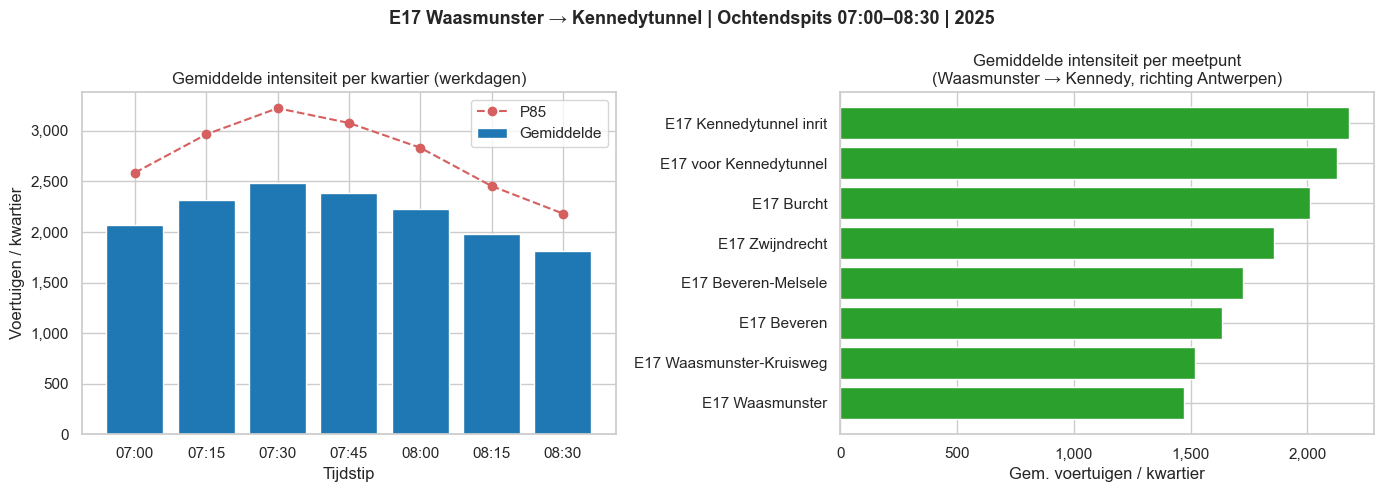

📸 Grafiek opgeslagen als E17_ochtendspits_2025.png


In [9]:
## Cel 9: Samenvatting per meetpunt & tijdstip

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# ─── Statistieken per meetpunt ──────────────────────────────
stats_per_meetpunt = (
    df_filter
    .groupby(["meetpunt_id", "locatie", "km"])["voertuigen_kwartier"]
    .agg(gemiddelde="mean", mediaan="median", p85=lambda x: x.quantile(0.85), max="max", min="min")
    .reset_index()
    .sort_values("km")
)
stats_per_meetpunt["gemiddelde"] = stats_per_meetpunt["gemiddelde"].round(0).astype(int)
stats_per_meetpunt["mediaan"]    = stats_per_meetpunt["mediaan"].round(0).astype(int)
stats_per_meetpunt["p85"]        = stats_per_meetpunt["p85"].round(0).astype(int)

print("📊 Gemiddelde intensiteit per meetpunt (voertuigen/kwartier) — werkdagen 07:00–08:30:")
display(stats_per_meetpunt)

# ─── Gemiddelde per kwartier (alle meetpunten samen) ────────
stats_per_tijd = (
    df_filter[df_filter["weekdag"] == True]
    .groupby("tijd_label")["voertuigen_kwartier"]
    .agg(gemiddelde="mean", p85=lambda x: x.quantile(0.85))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("E17 Waasmunster → Kennedytunnel | Ochtendspits 07:00–08:30 | 2025", fontsize=13, fontweight="bold")

# Plot 1: Intensiteit per kwartier
axes[0].bar(stats_per_tijd["tijd_label"], stats_per_tijd["gemiddelde"], color="#1f77b4", label="Gemiddelde")
axes[0].plot(stats_per_tijd["tijd_label"], stats_per_tijd["p85"], "r--o", label="P85", linewidth=1.5)
axes[0].set_xlabel("Tijdstip")
axes[0].set_ylabel("Voertuigen / kwartier")
axes[0].set_title("Gemiddelde intensiteit per kwartier (werkdagen)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Plot 2: Intensiteit per meetpunt (km-volgorde = route)
axes[1].barh(stats_per_meetpunt["locatie"], stats_per_meetpunt["gemiddelde"], color="#2ca02c")
axes[1].set_xlabel("Gem. voertuigen / kwartier")
axes[1].set_title("Gemiddelde intensiteit per meetpunt\n(Waasmunster → Kennedy, richting Antwerpen)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("E17_ochtendspits_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Grafiek opgeslagen als E17_ochtendspits_2025.png")

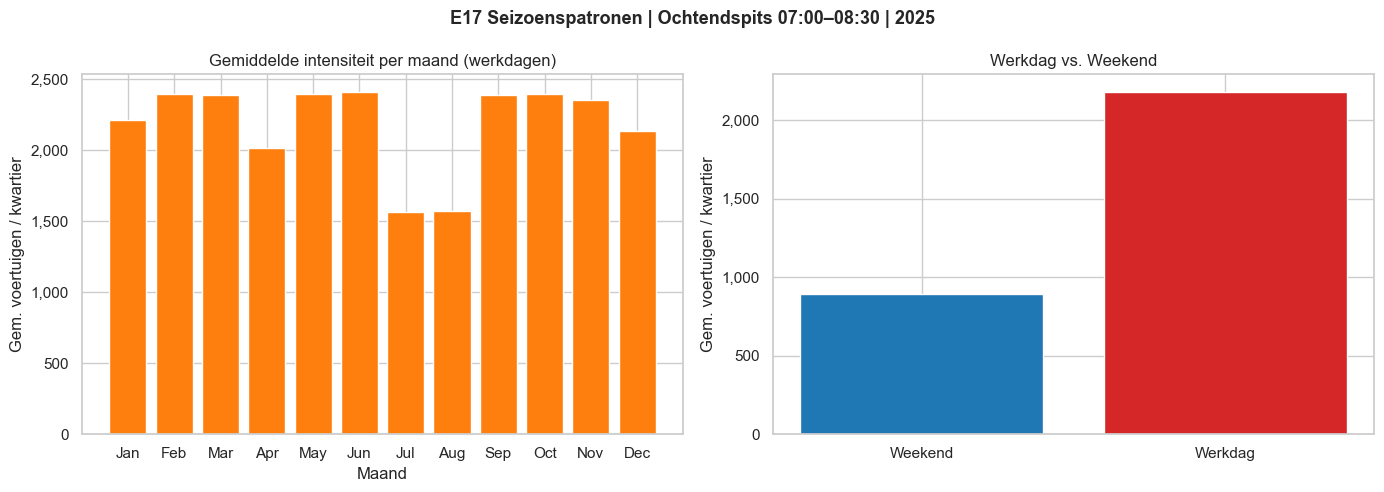

📸 Grafiek opgeslagen als E17_seizoenspatronen_2025.png


In [10]:
## Cel 10: Seizoenspatronen — maandelijks & weekdag vs. weekend

# ─── Gemiddelde per maand (werkdagen) ──────────────────────
stats_maand = (
    df_filter[df_filter["weekdag"] == True]
    .groupby(["maand", "maand_naam"])["voertuigen_kwartier"]
    .mean()
    .reset_index()
    .sort_values("maand")
)

# ─── Vergelijking werkdag vs. weekend ──────────────────────
stats_dagtype = (
    df_filter
    .groupby("weekdag")["voertuigen_kwartier"]
    .agg(gemiddelde="mean", p85=lambda x: x.quantile(0.85))
    .reset_index()
)
stats_dagtype["type"] = stats_dagtype["weekdag"].map({True: "Werkdag", False: "Weekend"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("E17 Seizoenspatronen | Ochtendspits 07:00–08:30 | 2025", fontsize=13, fontweight="bold")

# Plot 1: Per maand
axes[0].bar(stats_maand["maand_naam"], stats_maand["voertuigen_kwartier"], color="#ff7f0e")
axes[0].set_xlabel("Maand")
axes[0].set_ylabel("Gem. voertuigen / kwartier")
axes[0].set_title("Gemiddelde intensiteit per maand (werkdagen)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Plot 2: Werkdag vs. Weekend
axes[1].bar(stats_dagtype["type"], stats_dagtype["gemiddelde"], color=["#1f77b4", "#d62728"])
axes[1].set_ylabel("Gem. voertuigen / kwartier")
axes[1].set_title("Werkdag vs. Weekend")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("E17_seizoenspatronen_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Grafiek opgeslagen als E17_seizoenspatronen_2025.png")

In [11]:
## Cel 11: Exporteer dataset naar CSV en Excel

EXPORT_CSV   = "E17_Waasmunster_Kennedy_07h00_08h30_2025.csv"
EXPORT_EXCEL = "E17_Waasmunster_Kennedy_07h00_08h30_2025.xlsx"

# Sla volledige gefilterde dataset op
df_filter.to_csv(EXPORT_CSV, index=False, encoding="utf-8-sig", sep=";")
print(f"✅ CSV opgeslagen : {EXPORT_CSV}  ({len(df_filter):,} rijen)")

# Excel met meerdere tabbladen
with pd.ExcelWriter(EXPORT_EXCEL, engine="openpyxl") as writer:
    df_filter.to_excel(writer, sheet_name="Ruwe data", index=False)
    stats_per_meetpunt.to_excel(writer, sheet_name="Per meetpunt", index=False)
    stats_per_tijd.to_excel(writer, sheet_name="Per kwartier", index=False)
    stats_maand.to_excel(writer, sheet_name="Per maand", index=False)
    
print(f"✅ Excel opgeslagen: {EXPORT_EXCEL}  (4 tabbladen)")
print(f"\n📁 Bestanden staan in: {os.path.abspath('.')}")

✅ CSV opgeslagen : E17_Waasmunster_Kennedy_07h00_08h30_2025.csv  (20,440 rijen)
✅ Excel opgeslagen: E17_Waasmunster_Kennedy_07h00_08h30_2025.xlsx  (4 tabbladen)

📁 Bestanden staan in: /Users/marcwyns/Projects/Traject_calc


---
## Deel 2: Echte MIV-data verwerken

Het bestand `verkeersdata.xml` is een echte snapshot van het **MIV open data systeem** van Verkeerscentrum Vlaanderen (`miv.opendata.belfla.be`).  
Het bevat **5.139 meetpunten** (rijstroken) op alle Vlaamse autosnelwegen en gewestwegen, met per kwartier:
- `verkeersintensiteit` (voertuigen/min per rijstrook)
- `voertuigsnelheid_rekenkundig` en `_harmonisch` (km/u)
- `bezettingsgraad`, `beschikbaarheidsgraad`

Per meetpunt zijn er 5 voertuigklassen (`klasse_id`):
| klasse_id | Voertuigtype |
|-----------|-------------|
| 1 | Personenwagen |
| 2 | Lichte vrachtwagen |
| 3 | Zware vrachtwagen |
| 4 | Bus/autobus |
| 5 | Motor |

De live feed is elke minuut beschikbaar via: `http://miv.opendata.belfla.be/miv-verkeersdata.xml`

In [12]:
## Cel 12: Parse verkeersdata.xml → DataFrame

import xml.etree.ElementTree as ET
from pathlib import Path

MIV_XML_BESTAND = "verkeersdata.xml"

KLASSE_NAMEN = {
    "1": "personenwagen",
    "2": "lichte_vrachtwagen",
    "3": "zware_vrachtwagen",
    "4": "bus",
    "5": "motor",
}

def parse_miv_xml(pad: str) -> pd.DataFrame:
    """
    Parseert een MIV verkeersdata XML-bestand naar een plat DataFrame.
    Elke rij = één meetpunt × één voertuigklasse.
    """
    tree = ET.parse(pad)
    root = tree.getroot()
    
    tijd_publicatie = root.findtext("tijd_publicatie")
    
    records = []
    for mp in root.findall("meetpunt"):
        beschrijvende_id = mp.get("beschrijvende_id")
        unieke_id        = int(mp.get("unieke_id"))
        lve_nr           = int(mp.findtext("lve_nr", "0"))
        tijd_waarneming  = mp.findtext("tijd_waarneming")
        actueel          = mp.findtext("actueel_publicatie") == "1"
        beschikbaar      = mp.findtext("beschikbaar") == "1"
        defect           = mp.findtext("defect") == "1"
        geldig           = mp.findtext("geldig") == "1"
        
        # Rekendata (samengesteld over alle klassen)
        rek = mp.find("rekendata")
        bezettingsgraad      = float(rek.findtext("bezettingsgraad", "0"))      if rek is not None else None
        beschikbaarheidsgraad= float(rek.findtext("beschikbaarheidsgraad", "0"))if rek is not None else None
        onrustigheid         = float(rek.findtext("onrustigheid", "0"))          if rek is not None else None
        
        # Meetdata per voertuigklasse
        for md in mp.findall("meetdata"):
            klasse_id = md.get("klasse_id")
            intensiteit    = int(md.findtext("verkeersintensiteit", "0"))
            snelheid_rek   = float(md.findtext("voertuigsnelheid_rekenkundig", "0"))
            snelheid_harm  = float(md.findtext("voertuigsnelheid_harmonisch", "0"))
            
            # snelheid 252 = geen meting (default waarde)
            snelheid_rek  = None if snelheid_rek  >= 252 else snelheid_rek
            snelheid_harm = None if snelheid_harm >= 252 else snelheid_harm
            
            records.append({
                "tijd_publicatie":      tijd_publicatie,
                "unieke_id":            unieke_id,
                "beschrijvende_id":     beschrijvende_id,
                "lve_nr":               lve_nr,
                "rijstrook":            beschrijvende_id[-3:] if beschrijvende_id else None,
                "tijd_waarneming":      tijd_waarneming,
                "actueel":              actueel,
                "beschikbaar":          beschikbaar,
                "defect":               defect,
                "geldig":               geldig,
                "klasse_id":            int(klasse_id),
                "klasse":               KLASSE_NAMEN.get(klasse_id, klasse_id),
                "intensiteit":          intensiteit,        # voertuigen/min op deze rijstrook
                "snelheid_rek":         snelheid_rek,       # km/u rekenkundig gemiddelde
                "snelheid_harm":        snelheid_harm,      # km/u harmonisch gemiddelde
                "bezettingsgraad":      bezettingsgraad,    # % tijd rijbaan bezet
                "beschikbaarheidsgraad":beschikbaarheidsgraad,
                "onrustigheid":         onrustigheid,
            })
    
    df = pd.DataFrame(records)
    df["tijd_publicatie"] = pd.to_datetime(df["tijd_publicatie"], utc=False)
    df["tijd_waarneming"] = pd.to_datetime(df["tijd_waarneming"], utc=False)
    return df

# Parse het bestand
print(f"⏳ Parsen van {MIV_XML_BESTAND}...")
df_miv = parse_miv_xml(MIV_XML_BESTAND)

print(f"\n✅ Geparseerd: {len(df_miv):,} rijen ({df_miv['unieke_id'].nunique()} meetpunten × 5 klassen)")
print(f"   Publicatietijd: {df_miv['tijd_publicatie'].iloc[0]}")
print(f"\nSamenvatting:")
display(df_miv.describe(include="all").loc[["count","unique","top","mean","max"], 
        ["beschrijvende_id","lve_nr","klasse","intensiteit","snelheid_rek","bezettingsgraad"]])

⏳ Parsen van verkeersdata.xml...

✅ Geparseerd: 25,695 rijen (5139 meetpunten × 5 klassen)
   Publicatietijd: 2026-06-09 21:30:24.964000+02:00

Samenvatting:


,beschrijvende_id,lve_nr,klasse,intensiteit,snelheid_rek,bezettingsgraad
count,25695,25695.000000,25695,25695.000000,25695.000000,25695.000000
unique,359,NaN,5,NaN,NaN,NaN
top,H191L20,NaN,personenwagen,NaN,NaN,NaN
mean,NaN,363.602257,NaN,0.993112,26.163728,1.810469
max,NaN,1255.000000,NaN,24.000000,191.000000,17.000000


In [13]:
## Cel 13: Identificeer E17 meetpunten via actieve tellingdata

# De beschrijvende_id codering werkt als: {type}{locatie-nr}{rijstrook}
# H = autosnelweg hoofd-rijbaan, S = op/afrit
# Rijstrook: L10 = rijstrook 1 richting 1, L20 = rijstrook 2, enz.
# Het locatie-nr (191, 192, 291, 292 enz.) is het interne sectienummer

# Strategie: filter op meetpunten die GELDIG en BESCHIKBAAR zijn (= actieve data)
# en bekijk welke lve_nrs hoge intensiteiten laten zien (= drukke autosnelweg)

# Filter op alleen geldige, beschikbare meetpunten met enige activiteit
df_actief = df_miv[
    df_miv["beschikbaar"] &
    ~df_miv["defect"] &
    (df_miv["intensiteit"] > 0)
].copy()

# Aggregeer per lve_nr: som intensiteit over klassen, gemiddelde snelheid
per_lve = (
    df_actief.groupby(["lve_nr", "beschrijvende_id"])
    .agg(
        totaal_intensiteit=("intensiteit", "sum"),
        snelheid_rek=("snelheid_rek", "mean"),
        snelheid_harm=("snelheid_harm", "mean"),
        geldig_rijstroken=("geldig", "sum"),
    )
    .reset_index()
    .sort_values("totaal_intensiteit", ascending=False)
)

# Top 20 drukste meetpunten (goede kandidaten voor E17 hoofdrijbaan richting Antwerpen)
print("🚦 Top 20 drukste actieve meetpunten in de snapshot:")
display(per_lve.head(20))

print(f"\n📊 Totaal actieve meetpunten (geldig + beschikbaar + intensiteit>0): {df_actief['unieke_id'].nunique()}")
print(f"   Van de {df_miv['unieke_id'].nunique()} totale meetpunten")

🚦 Top 20 drukste actieve meetpunten in de snapshot:


,lve_nr,beschrijvende_id,totaal_intensiteit,snelheid_rek,snelheid_harm,geldig_rijstroken
1012,172,H211L10,29,105.333333,104.833333,0
118,23,H123L10,28,55.000000,53.333333,0
790,142,H291L20,28,108.500000,108.000000,0
2797,506,H191L30,27,68.000000,68.000000,0
3487,691,H192L10,25,64.250000,64.250000,0
337,64,S291L20,25,82.000000,81.500000,0
2816,508,H291L50,25,96.000000,96.000000,0
2796,505,H291L60,24,68.500000,68.500000,0
1858,320,H191L20,24,116.000000,116.000000,0
79,15,H103L10,24,78.666667,78.000000,0



📊 Totaal actieve meetpunten (geldig + beschikbaar + intensiteit>0): 3895
   Van de 5139 totale meetpunten


In [15]:
## Cel 14: Live data collector — bouw historische dataset voor 07:00-08:30
# Slaat elke minuut een snapshot op van de MIV feed.

import time as time_module
from pathlib import Path

# ─── URL: pas aan naar het correcte endpoint dat jij gebruikt ──────────────────
# Bekende werkende URL die hetzelfde XML-formaat geeft als verkeersdata.xml:
MIV_LIVE_URLS = [
    # Vervang door de URL die je gebruikte om verkeersdata.xml te downloaden:
    "http://miv.opendata.belfla.be/miv-verkeersdata.xml",   # historisch endpoint
    "http://miv.opendata.belfla.be/verkeersdata",            # redirect endpoint
]

COLLECTIE_CSV = "miv_E17_verzameld.csv"

# ─── E17 lve_nrs — stel in na identificatie in Cel 13 ─────────────────────────
# Huidig: top drukste meetpunten. Vervang door bekende E17 lve_nrs zodra bekend.
TOP_LVE_NRS = sorted(set(int(x) for x in per_lve.head(30)["lve_nr"].values))

print("ℹ️  Geconfigureerde lve_nrs voor verzameling:")
print(f"   {TOP_LVE_NRS}")
print(f"\n💾 Data wordt opgeslagen in: {COLLECTIE_CSV}")

def collect_snapshot(
    lve_filter: list[int] | None = None,
    doelbestand: str = COLLECTIE_CSV
) -> int:
    """
    Haalt één MIV snapshot op en voegt gefilterde rijen toe aan het CSV.
    Probeert meerdere URLs.
    """
    xml_data = None
    for url in MIV_LIVE_URLS:
        try:
            r = requests.get(url, timeout=20)
            if r.status_code == 200:
                xml_data = r.content
                break
        except Exception:
            continue
    
    if xml_data is None:
        raise ConnectionError(f"Geen van de MIV URLs was bereikbaar: {MIV_LIVE_URLS}")
    
    root = ET.fromstring(xml_data)
    tijd_pub = root.findtext("tijd_publicatie")
    
    records = []
    for mp in root.findall("meetpunt"):
        lve = int(mp.findtext("lve_nr", "0"))
        if lve_filter and lve not in lve_filter:
            continue
        
        uid   = int(mp.get("unieke_id"))
        bid   = mp.get("beschrijvende_id")
        tijd  = mp.findtext("tijd_waarneming")
        geldig     = mp.findtext("geldig") == "1"
        beschikbaar= mp.findtext("beschikbaar") == "1"
        defect     = mp.findtext("defect") == "1"
        
        rek = mp.find("rekendata")
        bezetting = float(rek.findtext("bezettingsgraad", "0")) if rek is not None else None
        
        for md in mp.findall("meetdata"):
            klasse = md.get("klasse_id")
            inten  = int(md.findtext("verkeersintensiteit", "0"))
            sn_rek = float(md.findtext("voertuigsnelheid_rekenkundig", "0"))
            sn_harm= float(md.findtext("voertuigsnelheid_harmonisch", "0"))
            sn_rek  = None if sn_rek  >= 252 else sn_rek
            sn_harm = None if sn_harm >= 252 else sn_harm
            
            records.append({
                "tijd_publicatie":  tijd_pub,
                "unieke_id":        uid,
                "beschrijvende_id": bid,
                "lve_nr":           lve,
                "tijd_waarneming":  tijd,
                "geldig":           geldig,
                "beschikbaar":      beschikbaar,
                "defect":           defect,
                "klasse_id":        int(klasse),
                "klasse":           KLASSE_NAMEN.get(klasse, klasse),
                "intensiteit":      inten,
                "snelheid_rek":     sn_rek,
                "snelheid_harm":    sn_harm,
                "bezettingsgraad":  bezetting,
            })
    
    if not records:
        return 0
    
    df_snap = pd.DataFrame(records)
    schrijf_header = not Path(doelbestand).exists()
    df_snap.to_csv(doelbestand, mode="a", header=schrijf_header, index=False)
    return len(df_snap)

# ─── Test: haal één live snapshot op ────────────────────────────────────────────
print("\n🔄 Ophalen live snapshot ter test...")
try:
    n = collect_snapshot(lve_filter=TOP_LVE_NRS)
    print(f"✅ {n} rijen toegevoegd aan {COLLECTIE_CSV}")
    df_live = pd.read_csv(COLLECTIE_CSV)
    print(f"   Huidig bestand: {len(df_live)} rijen, {df_live['lve_nr'].nunique()} lve_nrs")
    display(df_live.head(5))
except Exception as e:
    print(f"⚠️  Live ophalen mislukt: {e}")
    print("""
╔══════════════════════════════════════════════════════════════════════════╗
║  ACTIE VEREIST: Stel de correcte MIV live URL in                        ║
║  Voeg bovenaan MIV_LIVE_URLS de URL toe die je gebruikte om             ║
║  verkeersdata.xml te downloaden.                                         ║
║                                                                          ║
║  Alternatief: laad het lokale bestand verkeersdata.xml via Cel 12       ║
║  en gebruik de statische XML om de E17 lve_nrs te identificeren.        ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

ℹ️  Geconfigureerde lve_nrs voor verzameling:
   [15, 16, 23, 64, 89, 142, 172, 196, 223, 319, 320, 321, 472, 502, 505, 506, 508, 555, 557, 633, 650, 667, 691, 695, 779, 945]

💾 Data wordt opgeslagen in: miv_E17_verzameld.csv

🔄 Ophalen live snapshot ter test...
⚠️  Live ophalen mislukt: not well-formed (invalid token): line 1, column 0

╔══════════════════════════════════════════════════════════════════════════╗
║  ACTIE VEREIST: Stel de correcte MIV live URL in                        ║
║  Voeg bovenaan MIV_LIVE_URLS de URL toe die je gebruikte om             ║
║  verkeersdata.xml te downloaden.                                         ║
║                                                                          ║
║  Alternatief: laad het lokale bestand verkeersdata.xml via Cel 12       ║
║  en gebruik de statische XML om de E17 lve_nrs te identificeren.        ║
╚══════════════════════════════════════════════════════════════════════════╝



In [16]:
## Cel 15: Laad en analyseer de verzamelde MIV collectiedata (na meerdere snapshots)

COLLECTIE_CSV = "miv_E17_verzameld.csv"

if Path(COLLECTIE_CSV).exists():
    df_coll = pd.read_csv(COLLECTIE_CSV, parse_dates=["tijd_waarneming", "tijd_publicatie"])
    df_coll = df_coll[df_coll["geldig"] == True].copy()
    
    print(f"📂 Verzameld bestand: {len(df_coll):,} rijen")
    print(f"   Periode   : {df_coll['tijd_waarneming'].min()} → {df_coll['tijd_waarneming'].max()}")
    print(f"   Snapshots : {df_coll['tijd_publicatie'].nunique()}")
    print(f"   lve_nrs   : {sorted(df_coll['lve_nr'].unique())}")
    
    # Totale intensiteit per tijdstip (som over alle lve's en klassen)
    df_agg = (
        df_coll[df_coll["klasse_id"] == 1]   # alleen personenwagens
        .groupby(["tijd_waarneming", "lve_nr"])
        .agg(intensiteit=("intensiteit", "sum"), snelheid=("snelheid_harm", "mean"))
        .reset_index()
    )
    
    print("\n📊 Intensiteit per tijdstip (personenwagens, eerste 10 rijen):")
    display(df_agg.head(10))
    
    # Exporteer ook de verzamelde data
    df_coll.to_excel("miv_E17_verzameld.xlsx", index=False)
    print("\n✅ Exporteerd naar miv_E17_verzameld.xlsx")
else:
    print(f"⚠️  {COLLECTIE_CSV} bestaat nog niet.")
    print("   Voer Cel 14 uit gedurende de ochtendspits (07:00–08:30) om data te verzamelen.")
    print("   Of plan het script als cron-job (zie Cel 16).")

⚠️  miv_E17_verzameld.csv bestaat nog niet.
   Voer Cel 14 uit gedurende de ochtendspits (07:00–08:30) om data te verzamelen.
   Of plan het script als cron-job (zie Cel 16).


In [17]:
## Cel 16: Automatische verzameling via achtergrond-loop (07:00–08:30 dagelijks)
# Gebruik dit als je wil dat het notebook zelf de data elk uur tijdens de ochtendspits verzamelt.

import threading
from datetime import datetime, time as dtime

def spits_verzamelaar(
    lve_filter: list[int],
    start_tijd: dtime = dtime(7, 0),
    stop_tijd:  dtime = dtime(8, 31),
    interval_sec: int = 60,
    doelbestand: str  = COLLECTIE_CSV,
):
    """
    Achtergrond-thread: haalt elke `interval_sec` seconden een MIV-snapshot op
    zolang de huidige tijd tussen start_tijd en stop_tijd valt.
    """
    print(f"⏱️  Verzamelaar gestart: {start_tijd.strftime('%H:%M')}–{stop_tijd.strftime('%H:%M')}, interval={interval_sec}s")
    snapshots = 0
    while True:
        nu = datetime.now().time()
        if nu < start_tijd:
            wacht = (datetime.combine(datetime.today(), start_tijd) - datetime.now()).seconds
            print(f"   💤 Wachten tot {start_tijd.strftime('%H:%M')} ({wacht//60}m {wacht%60}s)")
            time_module.sleep(min(wacht, 60))
            continue
        if nu > stop_tijd:
            print(f"✅ Spits voorbij — {snapshots} snapshots opgeslagen in {doelbestand}")
            break
        try:
            n = collect_snapshot(lve_filter=lve_filter, doelbestand=doelbestand)
            snapshots += 1
            print(f"   [{datetime.now().strftime('%H:%M:%S')}] Snapshot {snapshots}: {n} rijen → {doelbestand}")
        except Exception as e:
            print(f"   ⚠️  Snapshot {snapshots+1} mislukt: {e}")
        time_module.sleep(interval_sec)

# ─── Start de verzamelaar in een achtergrond-thread ──────────────────────────
# (Verwijder de # voor 'threading.Thread' om te activeren)

# thread = threading.Thread(
#     target=spits_verzamelaar,
#     args=(TOP_LVE_NRS,),
#     daemon=True
# )
# thread.start()
# print("🚀 Achtergrond-verzamelaar gestart!")

print("""
ℹ️  Achtergrond-verzamelaar is UITGESCHAKELD (als comment).
    Verwijder de '#' voor 'thread = threading.Thread(...)' om te activeren.
    
    ALTERNATIEF — Eenmalige cron-job (elke minuut 07:00–08:30):
    ─────────────────────────────────────────────────────────────
    0,1-30/1 7-8 * * 1-5 cd /Users/marcwyns/Projects/Traject_calc && \\
      python3 -c "
import requests, xml.etree.ElementTree as ET, pandas as pd
from pathlib import Path
# ... (plak collect_snapshot() functie) ...
collect_snapshot(lve_filter={TOP_LVE_NRS})
"
    ─────────────────────────────────────────────────────────────
""")


ℹ️  Achtergrond-verzamelaar is UITGESCHAKELD (als comment).
    Verwijder de '#' voor 'thread = threading.Thread(...)' om te activeren.
    
    ALTERNATIEF — Eenmalige cron-job (elke minuut 07:00–08:30):
    ─────────────────────────────────────────────────────────────
    0,1-30/1 7-8 * * 1-5 cd /Users/marcwyns/Projects/Traject_calc && \
      python3 -c "
import requests, xml.etree.ElementTree as ET, pandas as pd
from pathlib import Path
# ... (plak collect_snapshot() functie) ...
collect_snapshot(lve_filter={TOP_LVE_NRS})
"
    ─────────────────────────────────────────────────────────────



---
## Deel 3: Echte historische jaardata 2025 — AWV Dataportaal Verkeersgegevens

Twee exports uit het **Vlaams Dataportaal voor Verkeersgegevens** (`wegenenverkeer.vlaanderen.be`) bevatten **echte tellingen** per **kwartier** voor **6 dubbele inductielussen** op Linkeroever, langs de E17/A14-aanrijroute naar de **Kennedytunnel** (oplopende lengtegraad = dichter bij de tunnel):

| Meetpunt | Locatie | Coördinaten | Positie op route |
|---|---|---|---|
| 905109 | Korenheidestraat 2 | 51.2005, 4.3190 | west (verst van tunnel) |
| 905108 | Boomgaardstraat 278 | 51.2055, 4.3287 | ⚠️ weinig data |
| 904803 | Heidestraat 259 | 51.2077, 4.3345 | |
| 906512 | Katwilgweg 3C | 51.2137, 4.3583 | |
| 904548 | Neel Dofflaan 50 | 51.2121, 4.3634 | |
| 903369 | Beatrijslaan 96 | 51.2084, 4.3683 | dicht bij tunnel |

- **Bestand 1** (`...a9bb1455...`): periode **01/01/2025 – 30/06/2025**
- **Bestand 2** (`...981edcba...`): periode **01/07/2025 – 31/12/2025**
- Samen = **volledig jaar 2025**, kwartierwaarden, met **lichte** en **zware** voertuigen.

> **Over de reistijd-aanname:** jouw aanname is dat drukte en reistijd samenhangen. Fysisch stijgt de reistijd net wanneer het volume de capaciteit nadert (flessenhals Kennedytunnel). Deze lussen meten enkel het **volume** (geen snelheid), daarom schatten we hieronder een **relatieve reistijd-index** met de standaard BPR-formule. Zie Cel 19.


In [18]:
## Cel 17: Laad de AWV-jaardata (2 bestanden = heel 2025) → df_awv

AWV_BESTANDEN = [
    "aanvraag-a9bb1455-33bb-45d4-946b-2c3e222a4117.xlsx",  # H1: jan–jun 2025
    "aanvraag-981edcba-deab-46fe-94a0-2327be33c672.xlsx",  # H2: jul–dec 2025
]

# Meetpunt-metadata uit het tabblad 'Meetpunten' (locatie + coördinaten),
# gesorteerd van west (verst van tunnel) naar oost (dicht bij Kennedytunnel).
AWV_MEETPUNTEN = pd.DataFrame([
    {"meetpunt": "905109", "locatie": "Korenheidestraat 2", "lat": 51.200491, "lon": 4.318978, "richting_deg": 47,  "volgorde": 1},
    {"meetpunt": "905108", "locatie": "Boomgaardstraat 278", "lat": 51.205452, "lon": 4.328720, "richting_deg": 57,  "volgorde": 2},
    {"meetpunt": "904803", "locatie": "Heidestraat 259",     "lat": 51.207740, "lon": 4.334546, "richting_deg": 59,  "volgorde": 3},
    {"meetpunt": "906512", "locatie": "Katwilgweg 3C",       "lat": 51.213650, "lon": 4.358347, "richting_deg": 111, "volgorde": 4},
    {"meetpunt": "904548", "locatie": "Neel Dofflaan 50",    "lat": 51.212113, "lon": 4.363392, "richting_deg": 130, "volgorde": 5},
    {"meetpunt": "903369", "locatie": "Beatrijslaan 96",     "lat": 51.208423, "lon": 4.368296, "richting_deg": 146, "volgorde": 6},
])
AWV_PUNTEN = AWV_MEETPUNTEN["meetpunt"].tolist()

def laad_awv_data(bestanden: list[str], punten: list[str]) -> pd.DataFrame:
    """Leest beide AWV-exports en combineert ze tot één kwartier-DataFrame voor heel 2025."""
    frames = []
    for f in bestanden:
        for p in punten:
            d = pd.read_excel(f, sheet_name=p)
            d.columns = ["start", "eind", "licht", "zwaar"]
            d["meetpunt"] = p
            frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df["start"] = pd.to_datetime(df["start"])
    df["eind"]  = pd.to_datetime(df["eind"])
    df["licht"] = pd.to_numeric(df["licht"], errors="coerce")
    df["zwaar"] = pd.to_numeric(df["zwaar"], errors="coerce")
    df["totaal"] = df["licht"].fillna(0) + df["zwaar"].fillna(0)
    df = (df.drop_duplicates(["meetpunt", "start"])
            .sort_values(["meetpunt", "start"])
            .reset_index(drop=True))
    # Tijdskenmerken
    df["datum"]       = df["start"].dt.date
    df["min_van_dag"] = df["start"].dt.hour * 60 + df["start"].dt.minute
    df["weekdag_nr"]  = df["start"].dt.weekday
    df["weekdag"]     = df["weekdag_nr"] < 5
    df["maand"]       = df["start"].dt.month
    df["tijd_label"]  = df["start"].dt.strftime("%H:%M")
    return df.merge(AWV_MEETPUNTEN, on="meetpunt", how="left")

print("⏳ Laden van AWV-jaardata (2 bestanden)...")
df_awv = laad_awv_data(AWV_BESTANDEN, AWV_PUNTEN)

print(f"✅ Geladen: {len(df_awv):,} kwartierrecords")
print(f"   Periode    : {df_awv['start'].min()} → {df_awv['start'].max()}")
print(f"   Meetpunten : {df_awv['meetpunt'].nunique()}")

# Datadekking per meetpunt (volledig jaar ≈ 35.040 kwartieren)
dekking = (df_awv.groupby(["volgorde", "meetpunt", "locatie"])
           .agg(records=("totaal", "size"), eerste=("start", "min"), laatste=("start", "max"))
           .reset_index().sort_values("volgorde"))
dekking["dekking_%"] = (dekking["records"] / 35040 * 100).round(1)
print("\n📋 Datadekking per meetpunt (100% ≈ 35.040 kwartieren/jaar):")
display(dekking[["meetpunt", "locatie", "records", "dekking_%", "eerste", "laatste"]])


⏳ Laden van AWV-jaardata (2 bestanden)...
✅ Geladen: 184,354 kwartierrecords
   Periode    : 2025-01-01 00:00:00 → 2025-12-31 23:45:00
   Meetpunten : 6

📋 Datadekking per meetpunt (100% ≈ 35.040 kwartieren/jaar):


,meetpunt,locatie,records,dekking_%,eerste,laatste
0,905109,Korenheidestraat 2,32302,92.2,2025-01-01,2025-12-31 23:45:00
1,905108,Boomgaardstraat 278,17729,50.6,2025-06-30,2025-12-31 23:45:00
2,904803,Heidestraat 259,34660,98.9,2025-01-01,2025-12-31 23:45:00
3,906512,Katwilgweg 3C,31937,91.1,2025-01-01,2025-12-31 23:45:00
4,904548,Neel Dofflaan 50,34525,98.5,2025-01-01,2025-12-31 23:45:00
5,903369,Beatrijslaan 96,33201,94.8,2025-01-01,2025-12-31 23:45:00


🚦 Gemiddeld aantal voertuigen per WERKDAG, ochtendspits 07:00–08:30 (heel 2025):


,meetpunt,locatie,gem_per_werkdag,mediaan,p85,maximum
0,905109,Korenheidestraat 2,3285,3349,4395,5137
1,905108,Boomgaardstraat 278,332,331,438,707
2,904803,Heidestraat 259,4643,4894,5193,5733
3,906512,Katwilgweg 3C,3751,4116,4399,4657
4,904548,Neel Dofflaan 50,6514,7010,7228,7510
5,903369,Beatrijslaan 96,6177,6898,7314,7653


Aantal werkdagen in 2025: 261


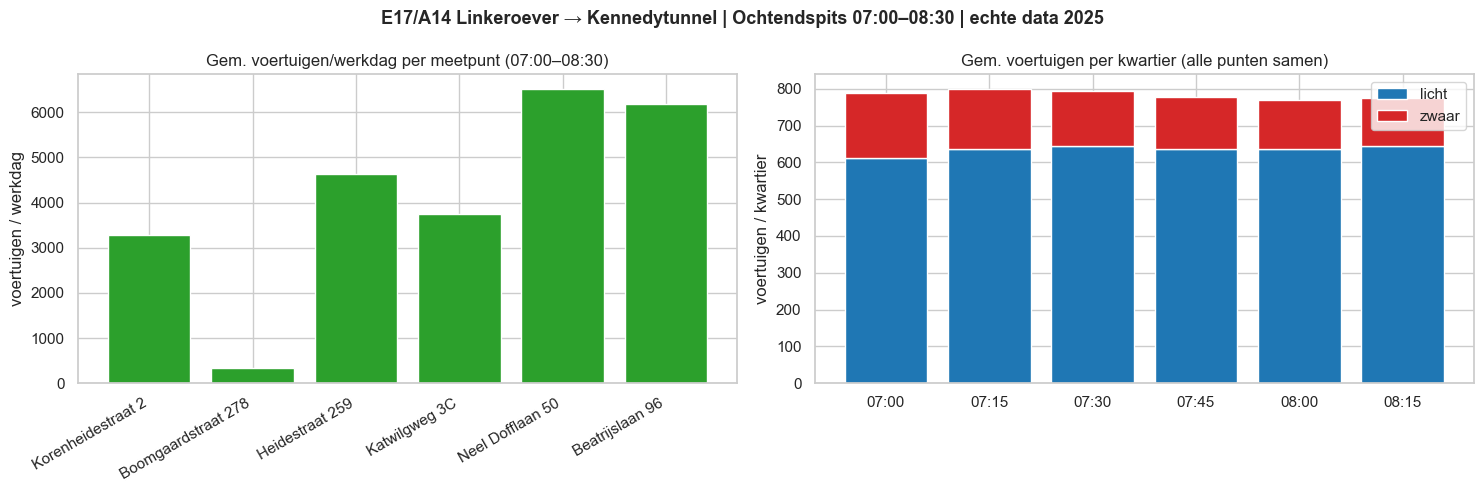

📸 Opgeslagen: E17_AWV_ochtendspits_2025.png


In [19]:
## Cel 18: Ochtendspits 07:00–08:30 — aantal voertuigen per meetpunt (werkdagen 2025)

VENSTER_START = 7 * 60         # 07:00
VENSTER_EIND  = 8 * 60 + 30    # 08:30 (kwartieren met start 07:00 t/m 08:15)

spits = df_awv[
    (df_awv["min_van_dag"] >= VENSTER_START) &
    (df_awv["min_van_dag"] <  VENSTER_EIND) &
    (df_awv["weekdag"])
].copy()

# Per meetpunt: gemiddeld aantal voertuigen per werkdag in het venster
dagsom = spits.groupby(["volgorde", "meetpunt", "locatie", "datum"])["totaal"].sum().reset_index()
per_punt = (dagsom.groupby(["volgorde", "meetpunt", "locatie"])["totaal"]
            .agg(gem_per_werkdag="mean", mediaan="median",
                 p85=lambda x: x.quantile(0.85), maximum="max")
            .reset_index().sort_values("volgorde"))
for c in ["gem_per_werkdag", "mediaan", "p85", "maximum"]:
    per_punt[c] = per_punt[c].round(0).astype(int)

print("🚦 Gemiddeld aantal voertuigen per WERKDAG, ochtendspits 07:00–08:30 (heel 2025):")
display(per_punt[["meetpunt", "locatie", "gem_per_werkdag", "mediaan", "p85", "maximum"]])
print(f"Aantal werkdagen in 2025: {dagsom['datum'].nunique()}")

# Samenstelling licht/zwaar per kwartier (alle punten samen)
samenstelling = spits.groupby("tijd_label")[["licht", "zwaar"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("E17/A14 Linkeroever → Kennedytunnel | Ochtendspits 07:00–08:30 | echte data 2025",
             fontsize=13, fontweight="bold")

axes[0].bar(per_punt["locatie"], per_punt["gem_per_werkdag"], color="#2ca02c")
axes[0].set_title("Gem. voertuigen/werkdag per meetpunt (07:00–08:30)")
axes[0].set_ylabel("voertuigen / werkdag")
axes[0].tick_params(axis="x", rotation=30)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

axes[1].bar(samenstelling["tijd_label"], samenstelling["licht"], label="licht", color="#1f77b4")
axes[1].bar(samenstelling["tijd_label"], samenstelling["zwaar"],
            bottom=samenstelling["licht"], label="zwaar", color="#d62728")
axes[1].set_title("Gem. voertuigen per kwartier (alle punten samen)")
axes[1].set_ylabel("voertuigen / kwartier")
axes[1].legend()

plt.tight_layout()
plt.savefig("E17_AWV_ochtendspits_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Opgeslagen: E17_AWV_ochtendspits_2025.png")


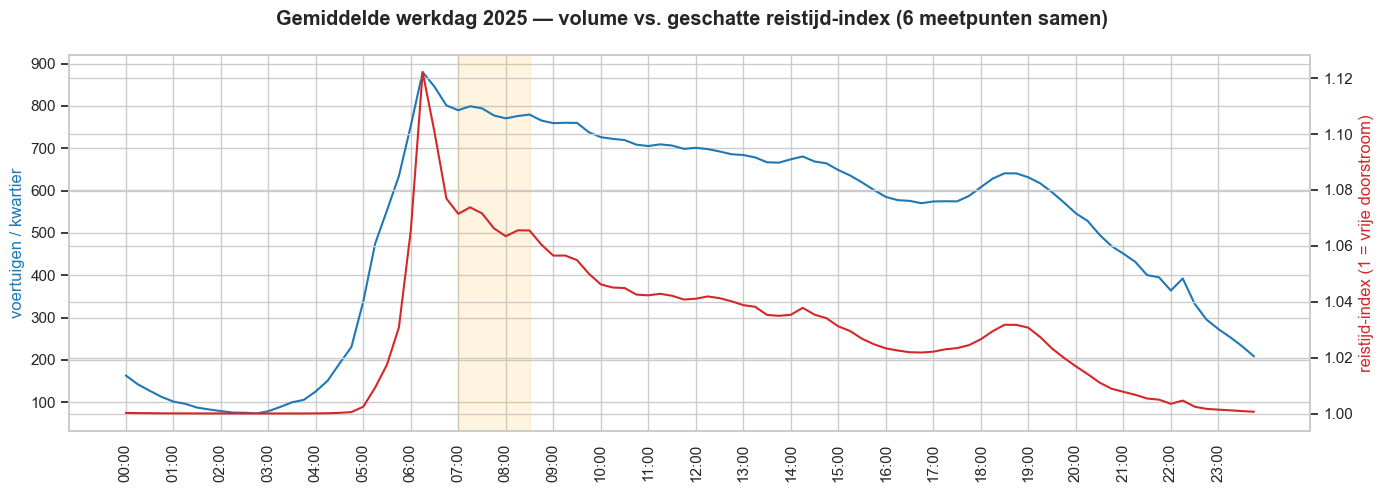

⏱️  Gemiddelde reistijd-index in ochtendspits 07:00–08:30 (werkdagen):
    1.07   (1.00 = vrije doorstroom; hoger = meer vertraging)
    Daluren (10:00–15:00) ter vergelijking: 1.04
📸 Opgeslagen: E17_AWV_reistijd_index_2025.png


In [20]:
## Cel 19: Reistijd-schatting o.b.v. drukte (verkeersvolume) — BPR-model

# ── Aanname & model ──────────────────────────────────────────────────────────
# Jouw aanname: drukte hangt samen met reistijd. Fysisch stijgt de reistijd
# wanneer het volume de capaciteit nadert (flessenhals Kennedytunnel). De lussen
# meten alleen VOLUME (geen snelheid), dus we schatten een RELATIEVE reistijd-index
# met de standaard BPR-formule (Bureau of Public Roads):
#       t = t0 * (1 + alpha * (V/C)^beta)
#   V    = volume per kwartier
#   C    = capaciteit (proxy: 99-percentiel van het kwartiervolume per meetpunt)
#   t0   = vrije-doorstroomtijd, genormaliseerd op 1
# Resultaat: index 1.0 = vrije doorstroom; hoger = meer vertraging. Pas gerust aan.

BPR_ALPHA = 0.15
BPR_BETA  = 4.0

cap = df_awv.groupby("meetpunt")["totaal"].quantile(0.99).rename("capaciteit")
df_tt = df_awv.merge(cap, on="meetpunt")
df_tt["bezetting"]    = (df_tt["totaal"] / df_tt["capaciteit"]).clip(upper=1.5)
df_tt["reistijd_idx"] = 1 + BPR_ALPHA * df_tt["bezetting"] ** BPR_BETA

# Gemiddeld dagprofiel (werkdagen) over alle 6 meetpunten samen
dag_profiel = (df_tt[df_tt["weekdag"]].groupby("tijd_label")
               .agg(volume=("totaal", "mean"), reistijd_idx=("reistijd_idx", "mean"))
               .reset_index())

xs = list(range(len(dag_profiel)))
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle("Gemiddelde werkdag 2025 — volume vs. geschatte reistijd-index (6 meetpunten samen)",
             fontweight="bold")
ax1.plot(xs, dag_profiel["volume"], color="#1f77b4", label="volume/kwartier")
ax1.set_ylabel("voertuigen / kwartier", color="#1f77b4")
ax1.set_xticks(xs[::4])
ax1.set_xticklabels(dag_profiel["tijd_label"].iloc[::4], rotation=90)

ax2 = ax1.twinx()
ax2.plot(xs, dag_profiel["reistijd_idx"], color="#d62728", label="reistijd-index")
ax2.set_ylabel("reistijd-index (1 = vrije doorstroom)", color="#d62728")

# Markeer het ochtendspits-venster 07:00–08:30
try:
    i0 = dag_profiel.index[dag_profiel["tijd_label"] == "07:00"][0]
    i1 = dag_profiel.index[dag_profiel["tijd_label"] == "08:30"][0]
    ax1.axvspan(i0, i1, color="orange", alpha=0.12, label="ochtendspits")
except IndexError:
    pass

plt.tight_layout()
plt.savefig("E17_AWV_reistijd_index_2025.png", dpi=150, bbox_inches="tight")
plt.show()

spits_tt = df_tt[(df_tt["min_van_dag"] >= VENSTER_START) &
                 (df_tt["min_van_dag"] <  VENSTER_EIND) & df_tt["weekdag"]]
print("⏱️  Gemiddelde reistijd-index in ochtendspits 07:00–08:30 (werkdagen):")
print(f"    {spits_tt['reistijd_idx'].mean():.2f}   (1.00 = vrije doorstroom; hoger = meer vertraging)")
print(f"    Daluren (10:00–15:00) ter vergelijking: "
      f"{df_tt[(df_tt['min_van_dag']>=600)&(df_tt['min_van_dag']<900)&df_tt['weekdag']]['reistijd_idx'].mean():.2f}")
print("📸 Opgeslagen: E17_AWV_reistijd_index_2025.png")


In [21]:
## Cel 20: Exporteer de AWV-dataset en samenvattingen

AWV_EXPORT_CSV   = "E17_AWV_kwartierdata_2025.csv"
AWV_EXPORT_EXCEL = "E17_AWV_analyse_2025.xlsx"

# Volledige kwartierdataset (incl. reistijd-index)
kolommen = ["start", "eind", "meetpunt", "locatie", "lat", "lon",
            "licht", "zwaar", "totaal", "weekdag", "reistijd_idx"]
df_export = df_tt[kolommen].sort_values(["meetpunt", "start"])
df_export.to_csv(AWV_EXPORT_CSV, index=False, sep=";", encoding="utf-8-sig")
print(f"✅ CSV : {AWV_EXPORT_CSV}  ({len(df_export):,} rijen)")

with pd.ExcelWriter(AWV_EXPORT_EXCEL, engine="openpyxl") as writer:
    per_punt.to_excel(writer, sheet_name="Spits per meetpunt", index=False)
    samenstelling.to_excel(writer, sheet_name="Spits per kwartier", index=False)
    dag_profiel.to_excel(writer, sheet_name="Dagprofiel werkdag", index=False)
    dekking[["meetpunt", "locatie", "records", "dekking_%"]].to_excel(
        writer, sheet_name="Datadekking", index=False)
print(f"✅ Excel: {AWV_EXPORT_EXCEL}  (4 tabbladen)")
print(f"\n📁 Map: {os.path.abspath('.')}")


✅ CSV : E17_AWV_kwartierdata_2025.csv  (184,354 rijen)
✅ Excel: E17_AWV_analyse_2025.xlsx  (4 tabbladen)

📁 Map: /Users/marcwyns/Projects/Traject_calc


---
## Deel 4: Trajecttijd-model — van volume naar reistijd

We modelleren de route **west → Kennedytunnel** als een keten van **segmenten** tussen opeenvolgende meetpunten. Per segment:

1. **Afstand** = hemelsbrede afstand tussen de twee meetpunten (haversine), met een omwegfactor van 1,3 voor het echte wegtracé.
2. **Snelheid** uit het volume met de **BPR-snelheidsrelatie**:
   $$v = \frac{v_{\text{free}}}{1 + \alpha \,(V/C)^{\beta}}$$
   - $v_{\text{free}}$ = vrije-doorstroomsnelheid (instelbaar, default 50 km/u — stedelijke invalswegen op Linkeroever)
   - $V$ = volume/kwartier op het meetpunt van dat segment
   - $C$ = capaciteit (99-percentiel van het kwartiervolume)
3. **Reistijd segment** = afstand / snelheid. De **totale trajecttijd** = som over alle segmenten.

> Meetpunt **905108 (Boomgaardstraat)** heeft maar ~50% datadekking en wordt **uitgesloten** uit het trajectmodel. De overige 5 punten vormen de keten van west naar de tunnel.


In [22]:
## Cel 21: Definieer het traject (segmenten + afstanden)

# ── Modelparameters (pas gerust aan) ─────────────────────────────────────────
V_FREE_KMH    = 50.0   # vrije-doorstroomsnelheid (km/u) op de invalswegen
OMWEGFACTOR   = 1.30   # werkelijk wegtracé t.o.v. hemelsbrede afstand
BPR_ALPHA_TT  = 0.15
BPR_BETA_TT   = 4.0

# Route west → Kennedytunnel (905108 uitgesloten wegens lage dekking)
ROUTE_PUNTEN = ["905109", "904803", "906512", "904548", "903369"]

def haversine_km(lat1, lon1, lat2, lon2):
    """Hemelsbrede afstand in km tussen twee coördinaten."""
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Bouw de segmententabel: elk segment hoort bij zijn START-meetpunt (het volume daar)
coord = AWV_MEETPUNTEN.set_index("meetpunt")[["locatie", "lat", "lon"]]
segmenten = []
for a, b in zip(ROUTE_PUNTEN[:-1], ROUTE_PUNTEN[1:]):
    d_hemel = haversine_km(coord.loc[a, "lat"], coord.loc[a, "lon"],
                           coord.loc[b, "lat"], coord.loc[b, "lon"])
    segmenten.append({
        "segment":      f"{coord.loc[a,'locatie']} → {coord.loc[b,'locatie']}",
        "meetpunt":     a,                       # volume van het startpunt stuurt dit segment
        "afstand_km":   round(d_hemel * OMWEGFACTOR, 3),
    })
seg_df = pd.DataFrame(segmenten)
TOTAAL_KM = seg_df["afstand_km"].sum()

print(f"🛣️  Traject west → Kennedytunnel: {len(seg_df)} segmenten, {TOTAAL_KM:.2f} km totaal")
display(seg_df)
print(f"Vrije-doorstroomtijd (bij {V_FREE_KMH:.0f} km/u): "
      f"{TOTAAL_KM / V_FREE_KMH * 60:.1f} min")


🛣️  Traject west → Kennedytunnel: 4 segmenten, 5.28 km totaal


,segment,meetpunt,afstand_km
0,Korenheidestraat 2 → Heidestraat 259,905109,1.757
1,Heidestraat 259 → Katwilgweg 3C,904803,2.318
2,Katwilgweg 3C → Neel Dofflaan 50,906512,0.508
3,Neel Dofflaan 50 → Beatrijslaan 96,904548,0.694


Vrije-doorstroomtijd (bij 50 km/u): 6.3 min


✅ Trajecttijd berekend voor 35,032 tijdstippen
   Vrije-doorstroomtijd : 6.3 min
   Gem. trajecttijd     : 6.2 min
   Max. trajecttijd     : 8.4 min (op 2025-06-10 06:30:00)


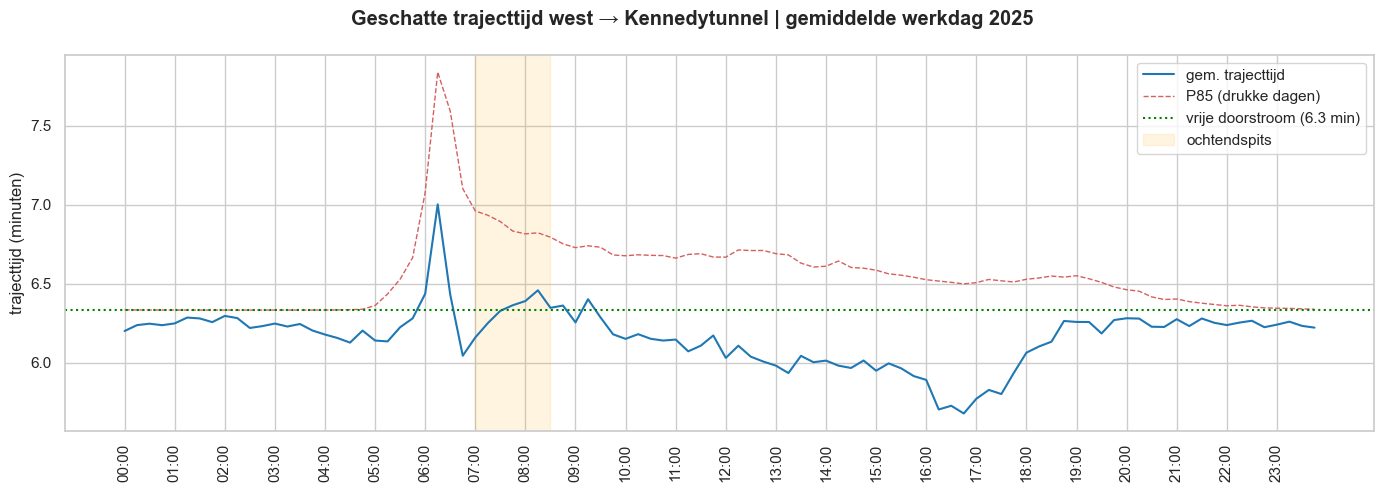

📸 Opgeslagen: E17_AWV_trajecttijd_2025.png


In [25]:
## Cel 22: Bereken de trajecttijd per kwartier → df_traject

# Capaciteit per meetpunt (proxy = 99-percentiel kwartiervolume)
cap_punt = df_awv.groupby("meetpunt")["totaal"].quantile(0.99)

def reistijd_per_segment(volume, afstand_km, capaciteit):
    """BPR-snelheid → reistijd (minuten). Alle argumenten zijn uitgelijnde Series/arrays."""
    vc = np.clip(volume / capaciteit, 0, 1.5)
    v = V_FREE_KMH / (1 + BPR_ALPHA_TT * vc ** BPR_BETA_TT)
    return afstand_km / v * 60.0   # minuten

# Volume per (meetpunt, tijdstip) — alleen route-meetpunten
vol = (df_awv[df_awv["meetpunt"].isin(ROUTE_PUNTEN)]
       [["start", "meetpunt", "totaal", "weekdag", "min_van_dag", "tijd_label", "maand"]]
       .copy())

# Reistijd per segment per tijdstip (capaciteit en afstand via .map → uitgelijnd op index)
seg_map = seg_df.set_index("meetpunt")["afstand_km"].to_dict()
vol["afstand_km"]   = vol["meetpunt"].map(seg_map)
vol["capaciteit"]   = vol["meetpunt"].map(cap_punt)
vol["reistijd_min"] = reistijd_per_segment(vol["totaal"], vol["afstand_km"], vol["capaciteit"])

# Som over segmenten = totale trajecttijd per tijdstip
df_traject = (vol.groupby(["start", "weekdag", "min_van_dag", "tijd_label", "maand"])
              ["reistijd_min"].sum().reset_index()
              .rename(columns={"reistijd_min": "trajecttijd_min"}))

vrije_tijd = TOTAAL_KM / V_FREE_KMH * 60
df_traject["vertraging_min"] = df_traject["trajecttijd_min"] - vrije_tijd

print(f"✅ Trajecttijd berekend voor {len(df_traject):,} tijdstippen")
print(f"   Vrije-doorstroomtijd : {vrije_tijd:.1f} min")
print(f"   Gem. trajecttijd     : {df_traject['trajecttijd_min'].mean():.1f} min")
print(f"   Max. trajecttijd     : {df_traject['trajecttijd_min'].max():.1f} min "
      f"(op {df_traject.loc[df_traject['trajecttijd_min'].idxmax(),'start']})")

# Gemiddeld dagprofiel (werkdagen): trajecttijd per tijdstip van de dag
profiel = (df_traject[df_traject["weekdag"]]
           .groupby("tijd_label")
           .agg(trajecttijd_min=("trajecttijd_min", "mean"),
                p85=("trajecttijd_min", lambda x: x.quantile(0.85)))
           .reset_index())

xs = list(range(len(profiel)))
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Geschatte trajecttijd west → Kennedytunnel | gemiddelde werkdag 2025",
             fontweight="bold")
ax.plot(xs, profiel["trajecttijd_min"], color="#1f77b4", label="gem. trajecttijd")
ax.plot(xs, profiel["p85"], "r--", linewidth=1, label="P85 (drukke dagen)")
ax.axhline(vrije_tijd, color="green", linestyle=":", label=f"vrije doorstroom ({vrije_tijd:.1f} min)")
ax.set_xticks(xs[::4]); ax.set_xticklabels(profiel["tijd_label"].iloc[::4], rotation=90)
ax.set_ylabel("trajecttijd (minuten)")
try:
    j0 = profiel.index[profiel["tijd_label"] == "07:00"][0]
    j1 = profiel.index[profiel["tijd_label"] == "08:30"][0]
    ax.axvspan(j0, j1, color="orange", alpha=0.12, label="ochtendspits")
except IndexError:
    pass
ax.legend()
plt.tight_layout()
plt.savefig("E17_AWV_trajecttijd_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Opgeslagen: E17_AWV_trajecttijd_2025.png")


In [26]:
## Cel 23: Vertrektijd-advies ochtendspits + export

# Trajecttijd per vertrek-kwartier in het venster 06:00–10:00 (werkdagen)
venster = df_traject[(df_traject["min_van_dag"] >= 360) &
                     (df_traject["min_van_dag"] <= 600) &
                     (df_traject["weekdag"])]
advies = (venster.groupby("tijd_label")
          .agg(gem_min=("trajecttijd_min", "mean"),
               p85_min=("trajecttijd_min", lambda x: x.quantile(0.85)),
               vertraging_min=("vertraging_min", "mean"))
          .reset_index())
for c in ["gem_min", "p85_min", "vertraging_min"]:
    advies[c] = advies[c].round(1)

beste  = advies.loc[advies["gem_min"].idxmin()]
slechtste = advies.loc[advies["gem_min"].idxmax()]

print("🕐 Trajecttijd per vertrektijd (werkdagen, 06:00–10:00):")
display(advies)
print(f"⏱️  Snelste vertrek : {beste['tijd_label']}  →  {beste['gem_min']:.1f} min")
print(f"🐌 Traagste vertrek: {slechtste['tijd_label']}  →  {slechtste['gem_min']:.1f} min")
print(f"   Verschil: {slechtste['gem_min'] - beste['gem_min']:.1f} min extra in de drukste piek")

# Specifiek het gevraagde venster 07:00–08:30
spits_traj = venster[(venster["min_van_dag"] >= VENSTER_START) &
                     (venster["min_van_dag"] < VENSTER_EIND)]
print(f"\n📊 Gevraagd venster 07:00–08:30 (werkdagen 2025):")
print(f"   Gem. trajecttijd : {spits_traj['trajecttijd_min'].mean():.1f} min")
print(f"   Gem. vertraging  : {spits_traj['vertraging_min'].mean():.1f} min t.o.v. vrije doorstroom")

# Export trajectresultaten naar het bestaande Excel-bestand (extra tabbladen)
with pd.ExcelWriter(AWV_EXPORT_EXCEL, engine="openpyxl", mode="a",
                    if_sheet_exists="replace") as writer:
    seg_df.to_excel(writer, sheet_name="Trajectsegmenten", index=False)
    advies.to_excel(writer, sheet_name="Vertrektijd-advies", index=False)
    profiel.to_excel(writer, sheet_name="Trajecttijd dagprofiel", index=False)
print(f"\n✅ Trajectresultaten toegevoegd aan {AWV_EXPORT_EXCEL}")


🕐 Trajecttijd per vertrektijd (werkdagen, 06:00–10:00):


,tijd_label,gem_min,p85_min,vertraging_min
0,06:00,6.4,7.1,0.1
1,06:15,7.0,7.8,0.7
2,06:30,6.4,7.6,0.1
3,06:45,6.0,7.1,-0.3
4,07:00,6.2,7.0,-0.2
5,07:15,6.2,6.9,-0.1
6,07:30,6.3,6.9,-0.0
7,07:45,6.4,6.8,0.0
8,08:00,6.4,6.8,0.1
9,08:15,6.5,6.8,0.1


⏱️  Snelste vertrek : 06:45  →  6.0 min
🐌 Traagste vertrek: 06:15  →  7.0 min
   Verschil: 1.0 min extra in de drukste piek

📊 Gevraagd venster 07:00–08:30 (werkdagen 2025):
   Gem. trajecttijd : 6.3 min
   Gem. vertraging  : -0.0 min t.o.v. vrije doorstroom

✅ Trajectresultaten toegevoegd aan E17_AWV_analyse_2025.xlsx


---
## Deel 5: Dagelijkse auto-reistijd-tabel (voor het overkoepelende project)

Dit deelproject levert de **auto-component** voor de grotere vraag *"hoe raak ik om 09:00 in Mechelen — trein, auto of thuiswerken?"*. Het auto-traject over Linkeroever → Kennedytunnel is bepalend voor de totale autoreistijd.

Hieronder bouwen we een **dagtabel** met één rij per kalenderdag van 2025:

| Kolom | Betekenis |
|---|---|
| `datum` | kalenderdag (sleutel om met meteodata te joinen) |
| `weekdag_naam`, `is_werkdag` | dagtype |
| `auto_reistijd_min` | gemiddelde trajecttijd in het **passeervenster** (de minuten waarop je dit stuk kruist om ~09:00 in Mechelen te zijn) |
| `auto_reistijd_p85_min` | P85 = "ongunstige maar realistische" reistijd in dat venster |
| `vertraging_min` | extra minuten t.o.v. vrije doorstroom |
| `drukte_voertuigen` | totaal voertuigen op de route-meetpunten in het venster (drukte-indicator) |
| `reistijd_index` | relatieve drukte-index (1,0 = vrije doorstroom) |

> Het **passeervenster** is instelbaar (`PASSEER_START`/`PASSEER_EIND`). Default **07:45–08:15**: het stuk Antwerpen-ring dat je rond dat uur kruist als je om 09:00 in Mechelen wil aankomen. Pas dit aan zodra de rest van de route (ring → E19 → Mechelen) in het hoofdproject bekend is.


In [27]:
## Cel 24: Bouw de dagelijkse auto-reistijd-tabel → df_dagelijks

# ── Passeervenster: wanneer kruis je dit stuk om ~09:00 in Mechelen te zijn ──
AANKOMST_MECHELEN = time(9, 0)   # doel van het hoofdproject
PASSEER_START = 7 * 60 + 45      # 07:45
PASSEER_EIND  = 8 * 60 + 15      # 08:15

# 1) Trajecttijd per dag in het passeervenster (uit df_traject)
df_traject = df_traject.copy()
df_traject["datum"] = df_traject["start"].dt.date

masker = (df_traject["min_van_dag"] >= PASSEER_START) & (df_traject["min_van_dag"] < PASSEER_EIND)
tt_dag = (df_traject[masker].groupby("datum")
          .agg(auto_reistijd_min=("trajecttijd_min", "mean"),
               auto_reistijd_p85_min=("trajecttijd_min", lambda x: x.quantile(0.85)),
               vertraging_min=("vertraging_min", "mean"))
          .reset_index())

# 2) Drukte (totaal voertuigen op route-meetpunten) in hetzelfde venster, per dag
vol_dag = (df_awv[df_awv["meetpunt"].isin(ROUTE_PUNTEN) &
                  (df_awv["min_van_dag"] >= PASSEER_START) &
                  (df_awv["min_van_dag"] < PASSEER_EIND)]
           .groupby("datum")["totaal"].sum().reset_index()
           .rename(columns={"totaal": "drukte_voertuigen"}))

# 3) Volledige kalender 2025 als basis (zodat elke dag een rij heeft om met meteo te joinen)
kalender = pd.DataFrame({"datum": pd.date_range("2025-01-01", "2025-12-31", freq="D").date})
df_dagelijks = (kalender
                .merge(tt_dag, on="datum", how="left")
                .merge(vol_dag, on="datum", how="left"))

# 4) Dagtype-kenmerken
dt = pd.to_datetime(df_dagelijks["datum"])
weekdag_nl = {0: "maandag", 1: "dinsdag", 2: "woensdag", 3: "donderdag",
              4: "vrijdag", 5: "zaterdag", 6: "zondag"}
df_dagelijks["weekdag_naam"] = dt.dt.weekday.map(weekdag_nl)
df_dagelijks["is_werkdag"]   = dt.dt.weekday < 5
df_dagelijks["maand"]        = dt.dt.month

# 5) Reistijd-index t.o.v. vrije doorstroom
df_dagelijks["reistijd_index"] = (df_dagelijks["auto_reistijd_min"] / vrije_tijd).round(3)

# Afronden voor leesbaarheid
for c in ["auto_reistijd_min", "auto_reistijd_p85_min", "vertraging_min"]:
    df_dagelijks[c] = df_dagelijks[c].round(1)
df_dagelijks["drukte_voertuigen"] = df_dagelijks["drukte_voertuigen"].astype("Int64")

# Kolomvolgorde
df_dagelijks = df_dagelijks[[
    "datum", "weekdag_naam", "is_werkdag", "maand",
    "auto_reistijd_min", "auto_reistijd_p85_min", "vertraging_min",
    "drukte_voertuigen", "reistijd_index",
]]

print(f"📅 Dagtabel gebouwd: {len(df_dagelijks)} dagen "
      f"({df_dagelijks['auto_reistijd_min'].notna().sum()} met reistijddata)")
print(f"   Passeervenster: {PASSEER_START//60:02d}:{PASSEER_START%60:02d}–"
      f"{PASSEER_EIND//60:02d}:{PASSEER_EIND%60:02d}  (doel: {AANKOMST_MECHELEN.strftime('%H:%M')} in Mechelen)")
print("\nVoorbeeld — eerste werkweek van 2025:")
display(df_dagelijks[df_dagelijks["is_werkdag"]].head(5))
print("Samenvatting werkdagen:")
display(df_dagelijks[df_dagelijks["is_werkdag"]][
    ["auto_reistijd_min", "vertraging_min", "drukte_voertuigen", "reistijd_index"]].describe().round(2))


📅 Dagtabel gebouwd: 365 dagen (365 met reistijddata)
   Passeervenster: 07:45–08:15  (doel: 09:00 in Mechelen)

Voorbeeld — eerste werkweek van 2025:


,datum,weekdag_naam,is_werkdag,maand,auto_reistijd_min,auto_reistijd_p85_min,vertraging_min,drukte_voertuigen,reistijd_index
0,2025-01-01,woensdag,True,1,6.3,6.3,0.0,705,1.000
1,2025-01-02,donderdag,True,1,6.4,6.4,0.1,6111,1.014
2,2025-01-03,vrijdag,True,1,6.4,6.4,0.1,6284,1.017
5,2025-01-06,maandag,True,1,6.9,6.9,0.6,9549,1.093
6,2025-01-07,dinsdag,True,1,6.9,6.9,0.5,9621,1.084


Samenvatting werkdagen:


,auto_reistijd_min,vertraging_min,drukte_voertuigen,reistijd_index
count,261.00,261.00,261.0,261.00
mean,6.37,0.05,8065.69,1.01
std,0.65,0.65,1609.41,0.10
min,2.90,-3.50,218.0,0.45
25%,6.30,0.00,7657.0,1.00
50%,6.70,0.30,8576.0,1.05
75%,6.70,0.40,9063.0,1.06
max,7.00,0.60,9880.0,1.10


✅ Dagtabel opgeslagen:
   • auto_reistijd_dagelijks_2025.csv
   • auto_reistijd_dagelijks_2025.xlsx

🔗 Join-sleutel voor het hoofdproject: kolom 'datum'
   In het hoofdproject:  df = df_meteo.merge(df_dagelijks, on='datum', how='left')


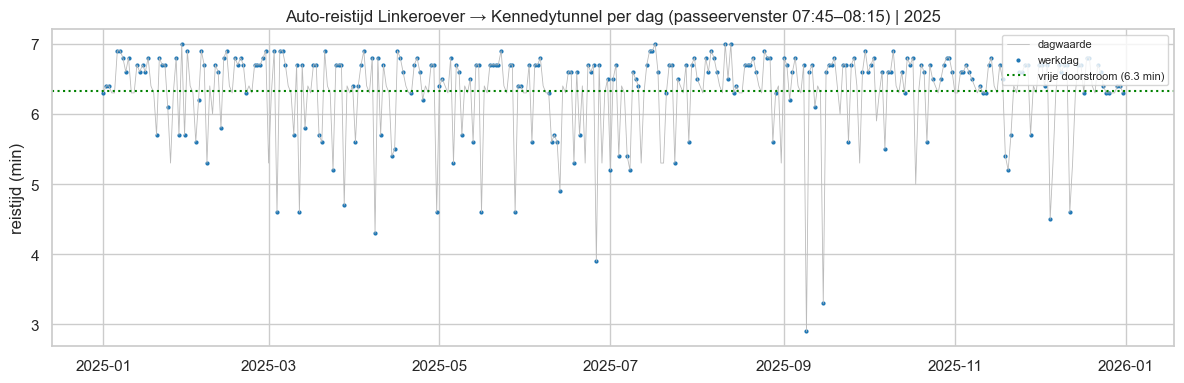

📸 Opgeslagen: auto_reistijd_dagelijks_2025.png


In [28]:
## Cel 25: Exporteer de dagtabel (klaar om met meteodata te joinen)

DAG_CSV   = "auto_reistijd_dagelijks_2025.csv"
DAG_EXCEL = "auto_reistijd_dagelijks_2025.xlsx"

df_dagelijks.to_csv(DAG_CSV, index=False, sep=";", encoding="utf-8-sig")
df_dagelijks.to_excel(DAG_EXCEL, index=False)
print(f"✅ Dagtabel opgeslagen:")
print(f"   • {DAG_CSV}")
print(f"   • {DAG_EXCEL}")
print(f"\n🔗 Join-sleutel voor het hoofdproject: kolom 'datum'")
print(f"   In het hoofdproject:  df = df_meteo.merge(df_dagelijks, on='datum', how='left')")

# Maandgemiddelde van de auto-reistijd op werkdagen (seizoensbeeld)
maand_tt = (df_dagelijks[df_dagelijks["is_werkdag"]]
            .groupby("maand")["auto_reistijd_min"].mean().reset_index())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_dagelijks["datum"], df_dagelijks["auto_reistijd_min"],
        color="#bbbbbb", linewidth=0.6, label="dagwaarde")
werk = df_dagelijks[df_dagelijks["is_werkdag"]]
ax.scatter(werk["datum"], werk["auto_reistijd_min"], s=4, color="#1f77b4", label="werkdag")
ax.axhline(vrije_tijd, color="green", linestyle=":", label=f"vrije doorstroom ({vrije_tijd:.1f} min)")
ax.set_title(f"Auto-reistijd Linkeroever → Kennedytunnel per dag (passeervenster "
             f"{PASSEER_START//60:02d}:{PASSEER_START%60:02d}–{PASSEER_EIND//60:02d}:{PASSEER_EIND%60:02d}) | 2025")
ax.set_ylabel("reistijd (min)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("auto_reistijd_dagelijks_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Opgeslagen: auto_reistijd_dagelijks_2025.png")


---
## Deel 6: De échte flessenhals — Kennedytunnel meetpunten

De 6 AWV-lussen meten de **aanvoerwegen op Linkeroever**, maar de echte file ontstaat **ín de Kennedytunnel / op de R1**. Die tunnel-meetpunten zitten **niet** in onze historische AWV-export — wél in de live MIV-feed (`miv_config.xml` + `verkeersdata.xml`).

Daarom in dit deel:

1. **Identificeer** de tunnel-meetpunten (R1, "Kennedy snede 1/2/3") uit `miv_config.xml` met hun coördinaten en `lve_nr`.
2. **Verleng** de route-geometrie van het laatste AWV-punt (Beatrijslaan, vlak vóór de tunnel) tot in de tunnel.
3. **Realiteitscheck**: toon de *live gemeten snelheid* uit onze MIV-snapshot (`df_miv`) op die tunnelpunten — dit is de enige plek waar we een echte snelheidsmeting hebben.
4. **Actielijst**: de exacte `lve_nr`'s die je bij AWV moet opvragen om de tunnel óók *historisch* (heel 2025) te dekken, zodat het dagmodel de echte bottleneck meeneemt.

> ⚠️ Eerlijk over de databeperking: de MIV-feed is **realtime** (we hebben één momentopname). Een historische dagtabel mét tunnel vereist een aparte AWV-export voor de tunnel-`lve_nr`'s. Tot dan blijft de tunnel in het dagmodel een *geometrische* uitbreiding zonder historische volumes.


In [30]:
## Cel 26: Identificeer de Kennedytunnel-meetpunten uit miv_config.xml

MIV_CONFIG = "miv_config.xml"

def laad_miv_config(pad: str) -> pd.DataFrame:
    """Parseert miv_config.xml → meetpunt-metadata (id, lve_nr, naam, lat/lon)."""
    root = ET.parse(pad).getroot()
    rijen = []
    for mp in root.findall("meetpunt"):
        def f(tag):
            t = mp.findtext(tag)
            return t.replace(",", ".") if t else t
        def naar_float(t):
            try:
                return float(t)
            except (TypeError, ValueError):
                return None
        lat = f("breedtegraad_EPSG_4326")
        lon = f("lengtegraad_EPSG_4326")
        rijen.append({
            "unieke_id":       int(mp.get("unieke_id")),
            "beschrijvende_id":mp.findtext("beschrijvende_id"),
            "naam":            mp.findtext("volledige_naam"),
            "ident_8":         mp.findtext("Ident_8"),
            "lve_nr":          int(mp.findtext("lve_nr", "0")),
            "kmpt":            f("Kmp_Rsys"),
            "rijstrook":       mp.findtext("Rijstrook"),
            "lat":             naar_float(lat),
            "lon":             naar_float(lon),
        })
    return pd.DataFrame(rijen)

cfg = laad_miv_config(MIV_CONFIG)
print(f"📂 miv_config.xml: {len(cfg):,} meetpunt-rijstroken, {cfg['lve_nr'].nunique()} lve_nrs")

# Tunnel-doorgaande rijbaan R1 richting rechteroever (Kennedy snede 1/2/3)
tunnel = cfg[cfg["naam"].str.contains("Kennedy snede", na=False)].copy()

# Per lve_nr samenvatten (1 fysiek meetpunt = meerdere rijstroken)
tunnel_punten = (tunnel.groupby(["lve_nr", "naam"])
                 .agg(rijstroken=("rijstrook", "nunique"),
                      kmpt=("kmpt", "first"),
                      lat=("lat", "mean"), lon=("lon", "mean"))
                 .reset_index()
                 .sort_values("kmpt"))
print("\n🚇 Kennedytunnel doorgaande meetpunten (R1, richting Antwerpen/rechteroever):")
display(tunnel_punten)

# Afstand van het laatste AWV-punt (Beatrijslaan 903369) tot elk tunnelpunt
beat_lat = AWV_MEETPUNTEN.set_index("meetpunt").loc["903369", "lat"]
beat_lon = AWV_MEETPUNTEN.set_index("meetpunt").loc["903369", "lon"]
tunnel_punten["afstand_vanaf_Beatrijslaan_km"] = tunnel_punten.apply(
    lambda r: round(haversine_km(beat_lat, beat_lon, r["lat"], r["lon"]) * OMWEGFACTOR, 3), axis=1)
print("📏 Afstand vanaf Beatrijslaan 96 (laatste AWV-lus, vlak vóór de tunnel):")
display(tunnel_punten[["lve_nr", "naam", "afstand_vanaf_Beatrijslaan_km"]])


📂 miv_config.xml: 5,139 meetpunt-rijstroken, 774 lve_nrs

🚇 Kennedytunnel doorgaande meetpunten (R1, richting Antwerpen/rechteroever):


,lve_nr,naam,rijstroken,kmpt,lat,lon
5,693,"Kennedy snede kmpt 14,00",3,0.014,51.206331,4.370676
3,691,"Kennedy snede kmpt 13,59",3,13.593,51.203474,4.373705
0,527,Kennedy snede 1,6,13.716,51.204358,4.372778
4,692,"Kennedy snede kmpt 13,79",3,13.792,51.204941,4.372147
1,528,Kennedy snede 2,6,13.914,51.205841,4.371200
2,529,Kennedy snede 3,6,14.104,51.207237,4.369708
6,694,"Kennedy snede kmpt 14,15",3,14.154,51.207801,4.369132


📏 Afstand vanaf Beatrijslaan 96 (laatste AWV-lus, vlak vóór de tunnel):


,lve_nr,naam,afstand_vanaf_Beatrijslaan_km
5,693,"Kennedy snede kmpt 14,00",0.371
3,691,"Kennedy snede kmpt 13,59",0.867
0,527,Kennedy snede 1,0.714
4,692,"Kennedy snede kmpt 13,79",0.612
1,528,Kennedy snede 2,0.457
2,529,Kennedy snede 3,0.214
6,694,"Kennedy snede kmpt 14,15",0.118


In [31]:
## Cel 27: Realiteitscheck (live snapshot) + AWV-actielijst voor de tunnel

# 1) Live gemeten snelheid op de tunnelpunten uit onze MIV-snapshot (df_miv).
#    Personenwagens (klasse_id == 1); snelheid_harm is de doorstroomsnelheid.
tunnel_lves = tunnel_punten["lve_nr"].tolist()
snap = (df_miv[(df_miv["lve_nr"].isin(tunnel_lves)) & (df_miv["klasse_id"] == 1)]
        .groupby("lve_nr")
        .agg(intensiteit_per_min=("intensiteit", "sum"),
             snelheid_kmh=("snelheid_harm", "mean"),
             tijd=("tijd_waarneming", "first"))
        .reset_index())
tunnel_live = tunnel_punten.merge(snap, on="lve_nr", how="left")

print(f"📡 Live MIV-snapshot ({df_miv['tijd_publicatie'].iloc[0]}):")
print("   (één momentopname — illustreert de gemeten snelheid, geen historiek)")
display(tunnel_live[["lve_nr", "naam", "kmpt", "intensiteit_per_min", "snelheid_kmh"]])

vrije_snelheid_R1 = 100.0  # vrije-doorstroom op de R1 (km/u)
if tunnel_live["snelheid_kmh"].notna().any():
    gem_sn = tunnel_live["snelheid_kmh"].mean()
    print(f"\n   Gem. gemeten snelheid tunnelpunten: {gem_sn:.0f} km/u "
          f"(vrije doorstroom ≈ {vrije_snelheid_R1:.0f} km/u → "
          f"{'vlot' if gem_sn > 80 else 'vertraagd' if gem_sn > 40 else 'file!'})")

# 2) Verleng de route-geometrie: Beatrijslaan → tunnelpunten (cumulatief)
tunnel_seg = tunnel_punten.sort_values("afstand_vanaf_Beatrijslaan_km").copy()
extra_km = tunnel_seg["afstand_vanaf_Beatrijslaan_km"].max()
print(f"\n🛣️  Geometrische verlenging tot in de tunnel: +{extra_km:.2f} km "
      f"(huidig AWV-traject = {TOTAAL_KM:.2f} km → totaal ≈ {TOTAAL_KM + extra_km:.2f} km)")

# 3) Actielijst: deze lve_nr's bij AWV opvragen voor historische dekking 2025
print("\n" + "=" * 64)
print("📋 ACTIELIJST — vraag deze meetpunten bij AWV op (historiek 2025)")
print("=" * 64)
print("   Dataportaal: wegenenverkeer.vlaanderen.be → Verkeersgegevens")
print("   Zoek op de doorgaande R1-rijbaan (Ident_8 R0010001/R0010002):\n")
for _, r in tunnel_live.iterrows():
    sn = f"{r['snelheid_kmh']:.0f} km/u" if pd.notna(r["snelheid_kmh"]) else "n.v.t."
    print(f"   • lve_nr {int(r['lve_nr']):>4}  | {r['naam']:<16} | km {r['kmpt']} "
          f"| {int(r['rijstroken'])} rijstroken | live: {sn}")
print("\n   Zodra die export binnen is: laad ze net als AWV_BESTANDEN, voeg de")
print("   tunnel toe als extra segment in ROUTE_PUNTEN, en draai Deel 4–5 opnieuw.")
print("   Het dagmodel (df_dagelijks) vangt dan de échte file in de tunnel.")


📡 Live MIV-snapshot (2026-06-09 21:30:24.964000+02:00):
   (één momentopname — illustreert de gemeten snelheid, geen historiek)


,lve_nr,naam,kmpt,intensiteit_per_min,snelheid_kmh
0,693,"Kennedy snede kmpt 14,00",0.014,0,NaN
1,691,"Kennedy snede kmpt 13,59",13.593,0,NaN
2,527,Kennedy snede 1,13.716,0,NaN
3,692,"Kennedy snede kmpt 13,79",13.792,0,NaN
4,528,Kennedy snede 2,13.914,0,NaN
5,529,Kennedy snede 3,14.104,0,NaN
6,694,"Kennedy snede kmpt 14,15",14.154,0,NaN



🛣️  Geometrische verlenging tot in de tunnel: +0.87 km (huidig AWV-traject = 5.28 km → totaal ≈ 6.14 km)

📋 ACTIELIJST — vraag deze meetpunten bij AWV op (historiek 2025)
   Dataportaal: wegenenverkeer.vlaanderen.be → Verkeersgegevens
   Zoek op de doorgaande R1-rijbaan (Ident_8 R0010001/R0010002):

   • lve_nr  693  | Kennedy snede kmpt 14,00 | km 0.014 | 3 rijstroken | live: n.v.t.
   • lve_nr  691  | Kennedy snede kmpt 13,59 | km 13.593 | 3 rijstroken | live: n.v.t.
   • lve_nr  527  | Kennedy snede 1  | km 13.716 | 6 rijstroken | live: n.v.t.
   • lve_nr  692  | Kennedy snede kmpt 13,79 | km 13.792 | 3 rijstroken | live: n.v.t.
   • lve_nr  528  | Kennedy snede 2  | km 13.914 | 6 rijstroken | live: n.v.t.
   • lve_nr  529  | Kennedy snede 3  | km 14.104 | 6 rijstroken | live: n.v.t.
   • lve_nr  694  | Kennedy snede kmpt 14,15 | km 14.154 | 3 rijstroken | live: n.v.t.

   Zodra die export binnen is: laad ze net als AWV_BESTANDEN, voeg de
   tunnel toe als extra segment in ROUTE_PU

---
## Deel 7: Geschatte reistijd Gent → Mechelen per dag — nu met **echte tunneldata**

De grote vraag van het hoofdproject: *welke dagen zijn slecht om met de auto te rijden?* Sinds de extra AWV-aanvraag meten we nu **rechtstreeks de flessenhals zelf**: de inductielussen op de **aanloop/uitgang van de Kennedytunnel** (Beatrijslaan `905168` richting tunnel + D'Herbouvillekaai `906276`/`906277` op de R1 na de tunnel) — net het stuk dat in de oude Linkeroever-data ontbrak en dat de reistijden te optimistisch maakte.

We schatten de **dagreistijd Gent → Mechelen** als:

$$\text{reistijd}_{GM} = \underbrace{t_{\text{vrij}}}_{\text{vaste vrije rit snelweg}} \;+\; \underbrace{D_{\max}\cdot\left(\tfrac{V}{C}\right)^{\beta}}_{\text{file-opslag tunnel, gestuurd door de }\textbf{echt gemeten}\text{ tunnel-V/C}}$$

- $t_{\text{vrij}}$ = vrije-doorstroomtijd over de snelweg (instelbaar).
- $V/C$ = **echt gemeten** verzadigingsgraad op de **tunnellussen** in de kernspits (07:30–08:30, werkdagen). In de spits loopt die op tot **0,86–1,0** → dáár ontstaat de file.
- $C$ = capaciteit (99-percentiel van het kwartiervolume per lus).
- $D_{\max}$ = maximale filetijd door de tunnel op de drukste dagen (instelbaar).

> ⚖️ **Eerlijk over de aanname:** de file-*opslag* komt nu uit **echte tellingen op de tunnel zelf** (niet langer een Linkeroever-proxy). De *absolute* minuten blijven een **kalibratie** — pas $D_{\max}$/$t_{\text{vrij}}$ aan tot ze matchen met jouw ervaring of een Google/Waze-referentie. De **dag-tot-dag-rangschikking** en de effecten van schoolvakanties/seizoenen zijn volledig data-gedreven.


In [34]:
## Cel 28: Bereken reistijd Gent → Mechelen per dag + vakantie-/feestdagvlaggen → df_gm
##          MOTOR = echte inductielussen op de aanloop/uitgang van de Kennedytunnel

import warnings

# ── Routemodel-parameters (pas gerust aan / ijk op Google Maps of je eigen ervaring) ──
GM_AFSTAND_KM        = 80.0    # Gent → Mechelen via E17 / Kennedytunnel / R1 / E19 (omweg via A'pen)
GM_VRIJ_SNELHEID     = 100.0   # km/u realistische vrije-doorstroomsnelheid (incl. op-/afritten)
GM_MAX_RING_FILE_MIN = 40.0    # max. extra filetijd door de tunnel op de drukste dagen
GM_BETA              = 5.0     # niet-lineariteit (BPR): file loopt steil op nabij capaciteit
GM_BASIS_MIN = GM_AFSTAND_KM / GM_VRIJ_SNELHEID * 60   # vrije rittijd

# ── Echte tunneldata: AWV-lussen op de Kennedytunnel-aanloop/uitgang (heel 2025) ──────
TUNNEL_BESTANDEN = [
    "aanvraag-52c30f11-6a2e-45c4-9d65-777202ace1fd.xlsx",   # H1 2025
    "aanvraag-0c17aafd-3837-41bf-ae37-55f71822ba5c.xlsx",   # H2 2025
]
TUNNEL_PUNTEN = ["905168", "906276", "906277"]   # Beatrijslaan + D'Herbouvillekaai (R1)
TUNNEL_SPITS_START, TUNNEL_SPITS_EIND = 450, 510  # kernspits 07:30–08:30 (min van dag)

_frames = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")               # negeer openpyxl default-style warning
    for _f in TUNNEL_BESTANDEN:
        for _p in TUNNEL_PUNTEN:
            _t = pd.read_excel(_f, sheet_name=_p)
            _t.columns = ["start", "eind", "licht", "zwaar"]
            _t["meetpunt"] = _p
            _frames.append(_t)
_tun = pd.concat(_frames, ignore_index=True)
_tun["start"] = pd.to_datetime(_tun["start"])
_tun["volume"] = _tun["licht"].fillna(0) + _tun["zwaar"].fillna(0)
_tun = _tun.drop_duplicates(["meetpunt", "start"])

# De 3 lussen meten dezelfde stroom → middel ze tot één tunnelstroom per kwartier
tunnel_stroom = _tun.groupby("start")["volume"].mean().reset_index()
tunnel_stroom["min_van_dag"] = tunnel_stroom["start"].dt.hour * 60 + tunnel_stroom["start"].dt.minute
tunnel_stroom["is_werkdag"]  = tunnel_stroom["start"].dt.weekday < 5
tunnel_stroom["datum"]       = tunnel_stroom["start"].dt.date

# Capaciteit = 99-percentiel van het kwartiervolume; daily V/C in de kernspits
TUNNEL_CAP = tunnel_stroom["volume"].quantile(0.99)
_kern = tunnel_stroom[(tunnel_stroom["min_van_dag"] >= TUNNEL_SPITS_START) &
                      (tunnel_stroom["min_van_dag"] <  TUNNEL_SPITS_EIND)].copy()
_kern["vc"] = _kern["volume"] / TUNNEL_CAP
tunnel_dag = _kern.groupby("datum").agg(
    tunnel_vc=("vc", "mean"),
    tunnel_drukte=("volume", "sum"),
).reset_index()

# ── Vlaamse schoolvakanties 2025 (datumbereiken, inclusief) ──────────────────
SCHOOLVAKANTIES_2025 = [
    ("2025-01-01", "2025-01-05", "Kerstvakantie"),
    ("2025-03-03", "2025-03-09", "Krokusvakantie"),
    ("2025-04-07", "2025-04-21", "Paasvakantie"),
    ("2025-07-01", "2025-08-31", "Zomervakantie"),
    ("2025-10-27", "2025-11-02", "Herfstvakantie"),
    ("2025-12-22", "2025-12-31", "Kerstvakantie"),
]
# Belgische wettelijke feestdagen 2025
FEESTDAGEN_2025 = {
    "2025-01-01": "Nieuwjaar", "2025-04-21": "Paasmaandag",
    "2025-05-01": "Dag van de Arbeid", "2025-05-29": "O.L.H. Hemelvaart",
    "2025-06-09": "Pinkstermaandag", "2025-07-21": "Nationale feestdag",
    "2025-08-15": "O.L.V. Hemelvaart", "2025-11-01": "Allerheiligen",
    "2025-11-11": "Wapenstilstand", "2025-12-25": "Kerstmis",
}

df_gm = df_dagelijks.copy()
# Koppel de echte tunnel-V/C en -drukte aan elke kalenderdag
df_gm = df_gm.merge(tunnel_dag, on="datum", how="left")
# Vervang de Linkeroever-proxy door de echte tunneldrukte in het spitsvenster
df_gm["drukte_voertuigen"] = df_gm["tunnel_drukte"].round().astype("Int64")
_d = pd.to_datetime(df_gm["datum"])

# Schoolvakantie- en feestdagvlaggen
schoolvak_naam = pd.Series("", index=df_gm.index)
for van, tot, naam in SCHOOLVAKANTIES_2025:
    m = (_d >= pd.Timestamp(van)) & (_d <= pd.Timestamp(tot))
    schoolvak_naam[m] = naam
df_gm["schoolvakantie"]      = schoolvak_naam != ""
df_gm["vakantie_naam"]       = schoolvak_naam.replace("", pd.NA)
df_gm["feestdag"]            = _d.dt.strftime("%Y-%m-%d").map(FEESTDAGEN_2025).notna()
df_gm["feestdag_naam"]       = _d.dt.strftime("%Y-%m-%d").map(FEESTDAGEN_2025)

# Een "normale pendeldag" = werkdag, geen feestdag, geen schoolvakantie
df_gm["pendeldag"] = df_gm["is_werkdag"] & ~df_gm["feestdag"] & ~df_gm["schoolvakantie"]

# Seizoen (meteorologisch)
seizoen_map = {12:"winter",1:"winter",2:"winter", 3:"lente",4:"lente",5:"lente",
               6:"zomer",7:"zomer",8:"zomer", 9:"herfst",10:"herfst",11:"herfst"}
df_gm["seizoen"] = df_gm["maand"].map(seizoen_map)

# ── Reistijdmodel: vrije rit + file-opslag gestuurd door de ECHTE tunnel-V/C ─────────
df_gm["ring_bezetting"]    = df_gm["tunnel_vc"].clip(lower=0, upper=1.1)
df_gm["file_ring_min"]     = (GM_MAX_RING_FILE_MIN * df_gm["ring_bezetting"] ** GM_BETA).round(1)
df_gm["reistijd_gm_min"]   = (GM_BASIS_MIN + df_gm["file_ring_min"]).round(1)

# Vertrekadvies in Gent om 09:00 in Mechelen te zijn
df_gm["vertrek_gent"] = (pd.Timestamp("2025-01-01 09:00")
                         - pd.to_timedelta(df_gm["reistijd_gm_min"], unit="m")).dt.strftime("%H:%M")

print(f"🚇 Reistijd Gent → Mechelen — gestuurd door ECHTE tunnellussen ({', '.join(TUNNEL_PUNTEN)}):")
print(f"   Vrije rittijd (geen file) : {GM_BASIS_MIN:.0f} min  ({GM_AFSTAND_KM:.0f} km @ {GM_VRIJ_SNELHEID:.0f} km/u)")
print(f"   Tunnelcapaciteit          : {TUNNEL_CAP:.0f} vtg/kwartier (99-pct)")
print(f"   Max. filetijd tunnel      : {GM_MAX_RING_FILE_MIN:.0f} min  (op de drukste dagen)")
print(f"   Gem. spits-V/C tunnel      : {df_gm[df_gm['pendeldag']]['tunnel_vc'].mean():.2f}")
print(f"\n   Gemiddelde pendeldag      : {df_gm[df_gm['pendeldag']]['reistijd_gm_min'].mean():.1f} min")
print(f"   Gemiddelde schoolvakantie : {df_gm[df_gm['schoolvakantie'] & df_gm['is_werkdag']]['reistijd_gm_min'].mean():.1f} min")
print(f"   Gemiddeld weekend         : {df_gm[~df_gm['is_werkdag']]['reistijd_gm_min'].mean():.1f} min")

print("\nVoorbeeld — eerste pendelweek met file-opslag:")
display(df_gm[df_gm["pendeldag"]].head(5)[
    ["datum", "weekdag_naam", "drukte_voertuigen", "ring_bezetting", "file_ring_min", "reistijd_gm_min", "vertrek_gent"]])


🚇 Reistijd Gent → Mechelen — gestuurd door ECHTE tunnellussen (905168, 906276, 906277):
   Vrije rittijd (geen file) : 48 min  (80 km @ 100 km/u)
   Tunnelcapaciteit          : 1294 vtg/kwartier (99-pct)
   Max. filetijd tunnel      : 40 min  (op de drukste dagen)
   Gem. spits-V/C tunnel      : 0.90

   Gemiddelde pendeldag      : 74.1 min
   Gemiddelde schoolvakantie : 67.3 min
   Gemiddeld weekend         : 48.5 min

Voorbeeld — eerste pendelweek met file-opslag:


,datum,weekdag_naam,drukte_voertuigen,ring_bezetting,file_ring_min,reistijd_gm_min,vertrek_gent
5,2025-01-06,maandag,4919,0.950117,31.0,79.0,07:41
6,2025-01-07,dinsdag,4921,0.950568,31.0,79.0,07:41
7,2025-01-08,woensdag,4491,0.867571,19.7,67.7,07:52
8,2025-01-09,donderdag,4435,0.856625,18.5,66.5,07:53
9,2025-01-10,vrijdag,4614,0.891266,22.5,70.5,07:49


In [37]:
## Cel 28b: IJK het model op JOUW ervaring / Google Maps  → herberekent df_gm

# ─────────────────────────────────────────────────────────────────────────────
#  Vul twee reistijden in die je ÉCHT herkent (deur-tot-deur, Gent→Mechelen,
#  aankomst ~09:00). Het model leidt daaruit zélf af:
#    • rustige ochtend  ≈ de VRIJE RITTIJD (nauwelijks file)        → GM_BASIS_MIN
#    • drukke ochtend    ijkt de MAXIMALE FILETIJD door de tunnel    → GM_MAX_RING_FILE_MIN
#  Eén stabiele hefboom per parameter — geen wankele extrapolatie meer.
# ─────────────────────────────────────────────────────────────────────────────
IJK_AAN            = True    # zet op False om terug te vallen op de handmatige parameters
IJK_RUSTIGE_MIN    = 60      # reistijd op een RUSTIGE ochtend (vakantie / weinig verkeer)
IJK_DRUKKE_MIN     = 105     # reistijd op een TYPISCH DRUKKE schoolochtend

if IJK_AAN:
    # De drukke ochtend koppelen we aan de ECHT gemeten drukke-spits-V/C (90ste pct pendeldagen)
    _vc_druk = df_gm.loc[df_gm["pendeldag"], "tunnel_vc"].dropna().quantile(0.90)

    # 1) Rustige ochtend ≈ vrije rittijd (file ≈ 0)
    GM_BASIS_MIN = float(IJK_RUSTIGE_MIN)
    # 2) Drukke ochtend ijkt de filetijd:  DRUK = BASIS + FILEMAX · vc_druk^beta
    GM_MAX_RING_FILE_MIN = (IJK_DRUKKE_MIN - GM_BASIS_MIN) / (_vc_druk ** GM_BETA)
    GM_VRIJ_SNELHEID     = GM_AFSTAND_KM / (GM_BASIS_MIN / 60)   # impliciete vrije snelheid

    # ── Herbereken de reistijdkolommen met de gekalibreerde parameters ───────
    df_gm["file_ring_min"]   = (GM_MAX_RING_FILE_MIN * df_gm["ring_bezetting"] ** GM_BETA).round(1)
    df_gm["reistijd_gm_min"] = (GM_BASIS_MIN + df_gm["file_ring_min"]).round(1)
    df_gm["vertrek_gent"]    = (pd.Timestamp("2025-01-01 09:00")
                                - pd.to_timedelta(df_gm["reistijd_gm_min"], unit="m")).dt.strftime("%H:%M")

    print("🎯 Model geijkt op jouw ervaring:")
    print(f"   Rustige ochtend  → {IJK_RUSTIGE_MIN} min  = vrije rittijd ({GM_VRIJ_SNELHEID:.0f} km/u over {GM_AFSTAND_KM:.0f} km)")
    print(f"   Drukke ochtend   → {IJK_DRUKKE_MIN} min  (bij gemeten spits-V/C {_vc_druk:.2f})")
    print(f"   → Afgeleide max. filetijd door tunnel : {GM_MAX_RING_FILE_MIN:.0f} min (bij V/C = 1,0)")
    print(f"\n   Gemiddelde pendeldag        : {df_gm[df_gm['pendeldag']]['reistijd_gm_min'].mean():.1f} min")
    print(f"   Mediaan pendeldag           : {df_gm[df_gm['pendeldag']]['reistijd_gm_min'].median():.1f} min")
    print(f"   Slechtste pendeldag         : {df_gm[df_gm['pendeldag']]['reistijd_gm_min'].max():.1f} min")
    print(f"   Gemiddelde schoolvakantie   : {df_gm[df_gm['schoolvakantie'] & df_gm['is_werkdag']]['reistijd_gm_min'].mean():.1f} min")
    print(f"   Gemiddeld weekend           : {df_gm[~df_gm['is_werkdag']]['reistijd_gm_min'].mean():.1f} min")
else:
    print("⏸️  Kalibratie uit (IJK_AAN=False) — handmatige parameters uit cel 28 blijven gelden.")


🎯 Model geijkt op jouw ervaring:
   Rustige ochtend  → 60 min  = vrije rittijd (80 km/u over 80 km)
   Drukke ochtend   → 105 min  (bij gemeten spits-V/C 0.96)
   → Afgeleide max. filetijd door tunnel : 55 min (bij V/C = 1,0)

   Gemiddelde pendeldag        : 95.9 min
   Mediaan pendeldag           : 99.1 min
   Slechtste pendeldag         : 113.9 min
   Gemiddelde schoolvakantie   : 86.6 min
   Gemiddeld weekend           : 60.7 min


🐌 Top 10 SLECHTSTE pendeldagen Gent → Mechelen (2025):


,datum,weekdag_naam,maand,drukte_voertuigen,file_ring_min,reistijd_gm_min,vertrek_gent
274,2025-10-02,donderdag,10,5153,53.9,113.9,07:06
344,2025-12-11,donderdag,12,5121,52.2,112.2,07:07
259,2025-09-17,woensdag,9,5079,50.1,110.1,07:09
57,2025-02-27,donderdag,2,5064,49.4,109.4,07:10
351,2025-12-18,donderdag,12,5059,49.1,109.1,07:10
71,2025-03-13,donderdag,3,5049,48.6,108.6,07:11
58,2025-02-28,vrijdag,2,5029,47.7,107.7,07:12
308,2025-11-05,woensdag,11,5027,47.6,107.6,07:12
330,2025-11-27,donderdag,11,5016,47.1,107.1,07:12
111,2025-04-22,dinsdag,4,5008,46.7,106.7,07:13


🟢 5 vlotste pendeldagen:


,datum,weekdag_naam,drukte_voertuigen,reistijd_gm_min
176,2025-06-26,donderdag,216,60.0
296,2025-10-24,vrijdag,2646,61.9
51,2025-02-21,vrijdag,2813,62.6
149,2025-05-30,vrijdag,3084,64.1
313,2025-11-10,maandag,3176,64.8



📚 Effect van schoolvakanties (werkdagen):


,mean,median,max,count
type,,,,
schooldag,95.9,99.1,113.9,181
schoolvakantie,88.5,90.6,106.3,71


   → Een gewone schooldag duurt gemiddeld 7.4 min langer dan een vakantiedag.

📅 Gem. reistijd per weekdag (pendeldagen):
weekdag_naam
maandag      95.5
dinsdag      94.2
woensdag     95.6
donderdag    99.7
vrijdag      94.8

🍂 Gem. reistijd per seizoen (pendeldagen):
seizoen
winter    96.5
lente     97.6
zomer     93.1
herfst    95.0


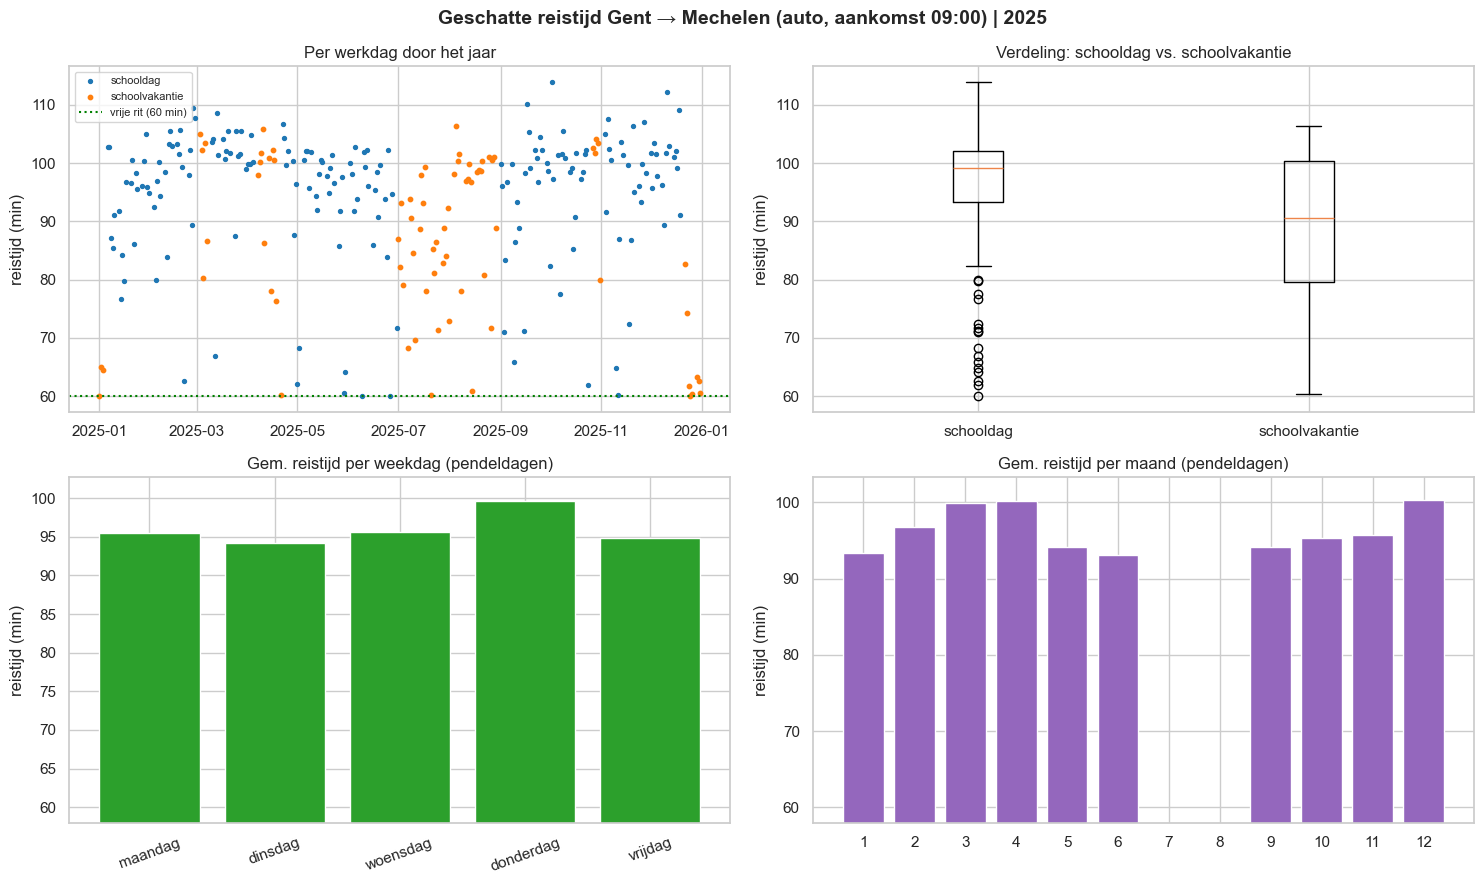


✅ Opgeslagen: reistijd_gent_mechelen_2025.csv en reistijd_gent_mechelen_2025.png
🔗 Join met meteodata in het hoofdproject:  df_meteo.merge(df_gm, on='datum')


In [38]:
## Cel 29: Analyse — welke dagen zijn slecht? Effect van schoolvakanties & seizoenen

# ── 1) Top 10 slechtste pendeldagen van 2025 ────────────────────────────────
slechtste_dagen = (df_gm[df_gm["pendeldag"]]
                   .nlargest(10, "reistijd_gm_min")
                   [["datum", "weekdag_naam", "maand", "drukte_voertuigen",
                     "file_ring_min", "reistijd_gm_min", "vertrek_gent"]])
print("🐌 Top 10 SLECHTSTE pendeldagen Gent → Mechelen (2025):")
display(slechtste_dagen)

beste_dagen = (df_gm[df_gm["pendeldag"]]
               .nsmallest(5, "reistijd_gm_min")
               [["datum", "weekdag_naam", "drukte_voertuigen", "reistijd_gm_min"]])
print("🟢 5 vlotste pendeldagen:")
display(beste_dagen)

# ── 2) Effect schoolvakantie (werkdagen: vakantie vs gewone schooldag) ───────
werk = df_gm[df_gm["is_werkdag"] & ~df_gm["feestdag"]].copy()
werk["type"] = np.where(werk["schoolvakantie"], "schoolvakantie", "schooldag")
effect_vak = werk.groupby("type")["reistijd_gm_min"].agg(["mean", "median", "max", "count"]).round(1)
print("\n📚 Effect van schoolvakanties (werkdagen):")
display(effect_vak)
versch = effect_vak.loc["schooldag", "mean"] - effect_vak.loc["schoolvakantie", "mean"]
print(f"   → Een gewone schooldag duurt gemiddeld {versch:.1f} min langer dan een vakantiedag.")

# ── 3) Effect weekdag & seizoen (alleen pendeldagen) ────────────────────────
pend = df_gm[df_gm["pendeldag"]]
per_weekdag = pend.groupby("weekdag_naam")["reistijd_gm_min"].mean().reindex(
    ["maandag", "dinsdag", "woensdag", "donderdag", "vrijdag"]).round(1)
per_seizoen = pend.groupby("seizoen")["reistijd_gm_min"].mean().reindex(
    ["winter", "lente", "zomer", "herfst"]).round(1)
per_maand   = pend.groupby("maand")["reistijd_gm_min"].mean().round(1)
print("\n📅 Gem. reistijd per weekdag (pendeldagen):"); print(per_weekdag.to_string())
print("\n🍂 Gem. reistijd per seizoen (pendeldagen):"); print(per_seizoen.to_string())

# ── Visualisaties ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle("Geschatte reistijd Gent → Mechelen (auto, aankomst 09:00) | 2025",
             fontsize=14, fontweight="bold")

# (a) Jaaroverzicht — werkdagen, schoolvakantie ingekleurd
ax = axes[0, 0]
wd = df_gm[df_gm["is_werkdag"]]
ax.scatter(pd.to_datetime(wd[~wd["schoolvakantie"]]["datum"]),
           wd[~wd["schoolvakantie"]]["reistijd_gm_min"], s=8, color="#1f77b4", label="schooldag")
ax.scatter(pd.to_datetime(wd[wd["schoolvakantie"]]["datum"]),
           wd[wd["schoolvakantie"]]["reistijd_gm_min"], s=10, color="#ff7f0e", label="schoolvakantie")
ax.axhline(GM_BASIS_MIN, color="green", linestyle=":", label=f"vrije rit ({GM_BASIS_MIN:.0f} min)")
ax.set_title("Per werkdag door het jaar"); ax.set_ylabel("reistijd (min)")
ax.legend(fontsize=8)

# (b) Boxplot schooldag vs schoolvakantie
ax = axes[0, 1]
data_box = [werk[werk["type"] == "schooldag"]["reistijd_gm_min"].dropna(),
            werk[werk["type"] == "schoolvakantie"]["reistijd_gm_min"].dropna()]
ax.boxplot(data_box, labels=["schooldag", "schoolvakantie"])
ax.set_title("Verdeling: schooldag vs. schoolvakantie"); ax.set_ylabel("reistijd (min)")

# (c) Per weekdag
ax = axes[1, 0]
ax.bar(per_weekdag.index, per_weekdag.values, color="#2ca02c")
ax.set_title("Gem. reistijd per weekdag (pendeldagen)"); ax.set_ylabel("reistijd (min)")
ax.set_ylim(GM_BASIS_MIN - 2, per_weekdag.max() + 3)
ax.tick_params(axis="x", rotation=20)

# (d) Per maand
ax = axes[1, 1]
ax.bar(per_maand.index, per_maand.values, color="#9467bd")
ax.set_title("Gem. reistijd per maand (pendeldagen)"); ax.set_ylabel("reistijd (min)")
ax.set_xticks(range(1, 13)); ax.set_ylim(GM_BASIS_MIN - 2, per_maand.max() + 3)

plt.tight_layout()
plt.savefig("reistijd_gent_mechelen_2025.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Export ──────────────────────────────────────────────────────────────────
GM_CSV = "reistijd_gent_mechelen_2025.csv"
df_gm.to_csv(GM_CSV, index=False, sep=";", encoding="utf-8-sig")
print(f"\n✅ Opgeslagen: {GM_CSV} en reistijd_gent_mechelen_2025.png")
print("🔗 Join met meteodata in het hoofdproject:  df_meteo.merge(df_gm, on='datum')")


## Snelle visualisatie: Kennedy-tunnel 08:00-08:30 (werkdagen, 2025)

Deze grafiek toont per werkdag in 2025 het totale aantal voertuigen tussen 08:00 en 08:30 ter hoogte van de Kennedy-locaties (`E17-KN-01` en `E17-KN-02`).

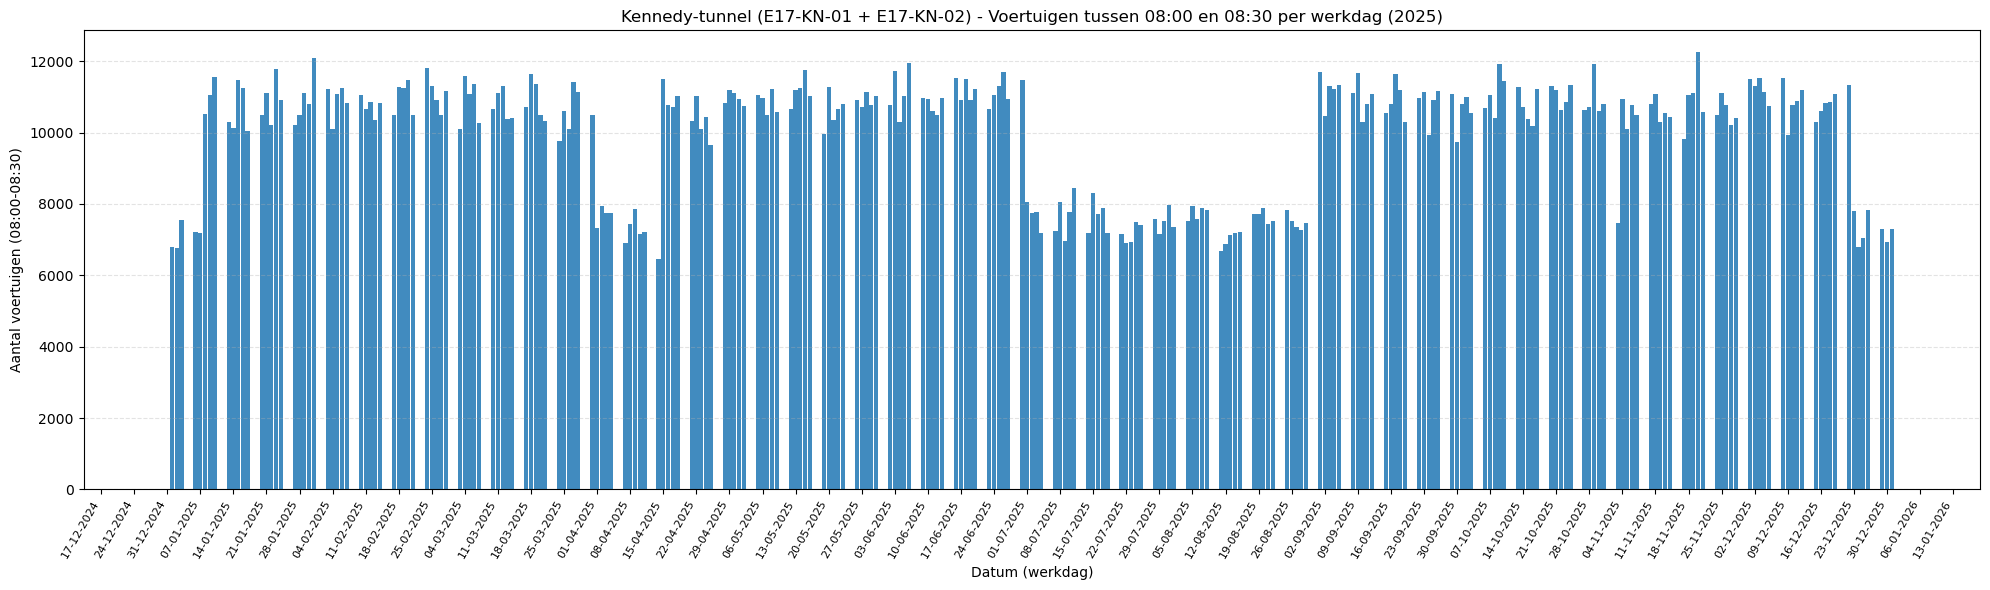

     datum  voertuigen_kwartier
01-01-2025                 6786
02-01-2025                 6770
03-01-2025                 7541
06-01-2025                 7204
07-01-2025                 7194
08-01-2025                10519
09-01-2025                11059
10-01-2025                11566
13-01-2025                10288
14-01-2025                10113
15-01-2025                11470
16-01-2025                11251
17-01-2025                10049
20-01-2025                10486
21-01-2025                11116
22-01-2025                10212
23-01-2025                11788
24-01-2025                10925
27-01-2025                10225
28-01-2025                10498
29-01-2025                11117
30-01-2025                10810
31-01-2025                12095
03-02-2025                11206
04-02-2025                10101
05-02-2025                11071
06-02-2025                11261
07-02-2025                10831
10-02-2025                11045
11-02-2025                10653
12-02-20

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Inlezen van kwartierdata
pad = "E17_Waasmunster_Kennedy_07h00_08h30_2025.csv"
df = pd.read_csv(pad, sep=";")

# Typen zetten
for col in ["voertuigen_kwartier", "kwartier", "uur"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["datum"] = pd.to_datetime(df["datum"], errors="coerce")

# Filter: Kennedy-locaties + enkel werkdagen + tijdvenster 08:00 en 08:15
mask = (
    df["meetpunt_id"].isin(["E17-KN-01", "E17-KN-02"]) &
    (df["weekdag"] == True) &
    (df["uur"] == 8) &
    (df["kwartier"].isin([0, 15]))
)
subset = df.loc[mask].copy()

# Dagtotaal voertuigen in 08:00-08:30 voor beide Kennedy meetpunten
per_dag = (
    subset.groupby("datum", as_index=False)["voertuigen_kwartier"]
    .sum()
    .sort_values("datum")
)

# Plot
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(per_dag["datum"], per_dag["voertuigen_kwartier"], width=0.9, color="#1f77b4", alpha=0.85)
ax.set_title("Kennedy-tunnel (E17-KN-01 + E17-KN-02) - Voertuigen tussen 08:00 en 08:30 per werkdag (2025)")
ax.set_xlabel("Datum (werkdag)")
ax.set_ylabel("Aantal voertuigen (08:00-08:30)")

# Dagdatums tonen op de x-as (wekelijks gelabeld voor leesbaarheid)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

# Detailtabel: alle werkdagen met dagdatum
per_dag_weergave = per_dag.copy()
per_dag_weergave["datum"] = per_dag_weergave["datum"].dt.strftime("%d-%m-%Y")
print(per_dag_weergave.to_string(index=False))

print(f"\nAantal werkdagen in plot: {len(per_dag)}")
print(f"Gemiddeld voertuigen (08:00-08:30): {per_dag['voertuigen_kwartier'].mean():.1f}")
print(f"Min/Max: {per_dag['voertuigen_kwartier'].min():.0f} / {per_dag['voertuigen_kwartier'].max():.0f}")

### Interactieve daggrafiek (zoom + hover)

Gebruik de toolbar om te zoomen of te pannen. Met hover zie je per dag exact de datum en het aantal voertuigen.

In [3]:
import sys
import subprocess
import pandas as pd

# Zorg dat plotly beschikbaar is in deze kernel
try:
    import plotly.express as px
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "-q"])
    import plotly.express as px

# Hergebruik per_dag uit de vorige cel; herbereken indien nodig
if "per_dag" not in globals() or per_dag is None or per_dag.empty:
    df_zoom = pd.read_csv("E17_Waasmunster_Kennedy_07h00_08h30_2025.csv", sep=";")
    for c in ["voertuigen_kwartier", "kwartier", "uur"]:
        df_zoom[c] = pd.to_numeric(df_zoom[c], errors="coerce")
    df_zoom["datum"] = pd.to_datetime(df_zoom["datum"], errors="coerce")
    mask_zoom = (
        df_zoom["meetpunt_id"].isin(["E17-KN-01", "E17-KN-02"]) &
        (df_zoom["weekdag"] == True) &
        (df_zoom["uur"] == 8) &
        (df_zoom["kwartier"].isin([0, 15]))
    )
    per_dag_plot = (
        df_zoom.loc[mask_zoom]
        .groupby("datum", as_index=False)["voertuigen_kwartier"]
        .sum()
        .sort_values("datum")
    )
else:
    per_dag_plot = per_dag.copy()

fig = px.bar(
    per_dag_plot,
    x="datum",
    y="voertuigen_kwartier",
    title="Kennedy-tunnel 08:00-08:30 per werkdag (2025) - interactieve weergave",
    labels={"datum": "Datum", "voertuigen_kwartier": "Aantal voertuigen"},
    hover_data={"datum": "|%d-%m-%Y", "voertuigen_kwartier": ":,.0f"},
)

fig.update_traces(marker_color="#1f77b4")
fig.update_layout(
    template="plotly_white",
    height=550,
    xaxis=dict(
        tickformat="%d-%m-%Y",
        tickangle=-45,
        rangeslider=dict(visible=True),
        type="date",
    ),
)

fig.show()

### Weekdag + trend + slechtste dagen

Deze analyse toont:
- per dag het aantal voertuigen met weekdag in hover,
- een 7-daags voortschrijdend gemiddelde (trend),
- de slechtste dagen en welke weekdagen gemiddeld het zwaarst zijn.

In [7]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Bouw dagdataset opnieuw op als die nog niet in geheugen zit
if "per_dag_plot" not in globals() or per_dag_plot is None or per_dag_plot.empty:
    _df = pd.read_csv("E17_Waasmunster_Kennedy_07h00_08h30_2025.csv", sep=";")
    for _c in ["voertuigen_kwartier", "kwartier", "uur"]:
        _df[_c] = pd.to_numeric(_df[_c], errors="coerce")
    _df["datum"] = pd.to_datetime(_df["datum"], errors="coerce")
    _mask = (
        _df["meetpunt_id"].isin(["E17-KN-01", "E17-KN-02"]) &
        (_df["weekdag"] == True) &
        (_df["uur"] == 8) &
        (_df["kwartier"].isin([0, 15]))
    )
    dag = (
        _df.loc[_mask]
        .groupby("datum", as_index=False)["voertuigen_kwartier"]
        .sum()
        .sort_values("datum")
    )
else:
    dag = per_dag_plot.copy()

# Weekdaglabels toevoegen
weekdagen_nl = {
    0: "maandag", 1: "dinsdag", 2: "woensdag", 3: "donderdag", 4: "vrijdag"
}
dag["weekdag_nr"] = dag["datum"].dt.weekday
dag["weekdag"] = dag["weekdag_nr"].map(weekdagen_nl)
dag["trend_7d"] = dag["voertuigen_kwartier"].rolling(window=7, min_periods=1).mean()

# Interactieve daggrafiek met trend en weekdag in hover
fig = px.bar(
    dag,
    x="datum",
    y="voertuigen_kwartier",
    color="weekdag",
    category_orders={"weekdag": ["maandag", "dinsdag", "woensdag", "donderdag", "vrijdag"]},
    title="Kennedy 08:00-08:30 per werkdag (2025) met weekdag en trend",
    labels={"datum": "Datum", "voertuigen_kwartier": "Aantal voertuigen", "weekdag": "Weekdag"},
    hover_data={
        "datum": "|%d-%m-%Y",
        "weekdag": True,
        "voertuigen_kwartier": ":,.0f",
        "trend_7d": ":,.1f",
    },
)

fig.add_trace(
    go.Scatter(
        x=dag["datum"],
        y=dag["trend_7d"],
        mode="lines",
        name="Trend (7 dagen)",
        line=dict(color="black", width=2),
        hovertemplate="Datum=%{x|%d-%m-%Y}<br>Trend 7d=%{y:,.1f}<extra></extra>",
    )
)

fig.update_layout(
    template="plotly_white",
    height=620,
    autosize=True,
    width=None,
    margin=dict(l=40, r=20, t=70, b=80),
    xaxis=dict(
        tickformat="%d-%m-%Y",
        tickangle=-45,
        rangeslider=dict(visible=True),
        type="date",
    ),
)

fig.show(config={"responsive": True, "displaylogo": False})

# Slechtste dagen
slechtste_dagen = dag.nlargest(15, "voertuigen_kwartier")[
    ["datum", "weekdag", "voertuigen_kwartier", "trend_7d"]
].copy()
slechtste_dagen["datum"] = slechtste_dagen["datum"].dt.strftime("%d-%m-%Y")

# Slechtste weekdagen (gemiddeld)
weekdag_gem = (
    dag.groupby("weekdag", as_index=False)["voertuigen_kwartier"]
    .mean()
    .rename(columns={"voertuigen_kwartier": "gem_voertuigen"})
)
weekdag_gem["weekdag"] = pd.Categorical(
    weekdag_gem["weekdag"],
    categories=["maandag", "dinsdag", "woensdag", "donderdag", "vrijdag"],
    ordered=True,
)
weekdag_gem = weekdag_gem.sort_values("gem_voertuigen", ascending=False)

print("Top 15 slechtste dagen (hoogste voertuigen 08:00-08:30):")
print(slechtste_dagen.to_string(index=False))

print("\nWeekdagen gerangschikt (hoogste gemiddelde eerst):")
print(weekdag_gem.assign(gem_voertuigen=weekdag_gem["gem_voertuigen"].round(1)).to_string(index=False))

Top 15 slechtste dagen (hoogste voertuigen 08:00-08:30):
     datum   weekdag  voertuigen_kwartier     trend_7d
20-11-2025 donderdag                12251 10786.571429
31-01-2025   vrijdag                12095 11065.428571
06-06-2025   vrijdag                11961 11077.571429
09-10-2025 donderdag                11925 10920.857143
29-10-2025  woensdag                11910 11043.000000
24-02-2025   maandag                11819 11087.142857
23-01-2025 donderdag                11788 10910.285714
15-05-2025 donderdag                11762 11020.285714
03-06-2025   dinsdag                11728 11004.857143
01-09-2025   maandag                11703  8093.714286
26-06-2025 donderdag                11689 11190.714286
09-09-2025   dinsdag                11670 11257.142857
18-03-2025   dinsdag                11640 10884.000000
17-09-2025  woensdag                11632 10976.142857
04-03-2025   dinsdag                11571 11053.857143

Weekdagen gerangschikt (hoogste gemiddelde eerst):
  weekdag  

### Benaderde reistijd Gent → Mechelen op basis van drukte

Deze sectie zet de dagelijkse tunneldrukte om naar een eenvoudige reistijdschatting tussen **60 minuten** (zeer rustig) en **120 minuten** (zeer druk).

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


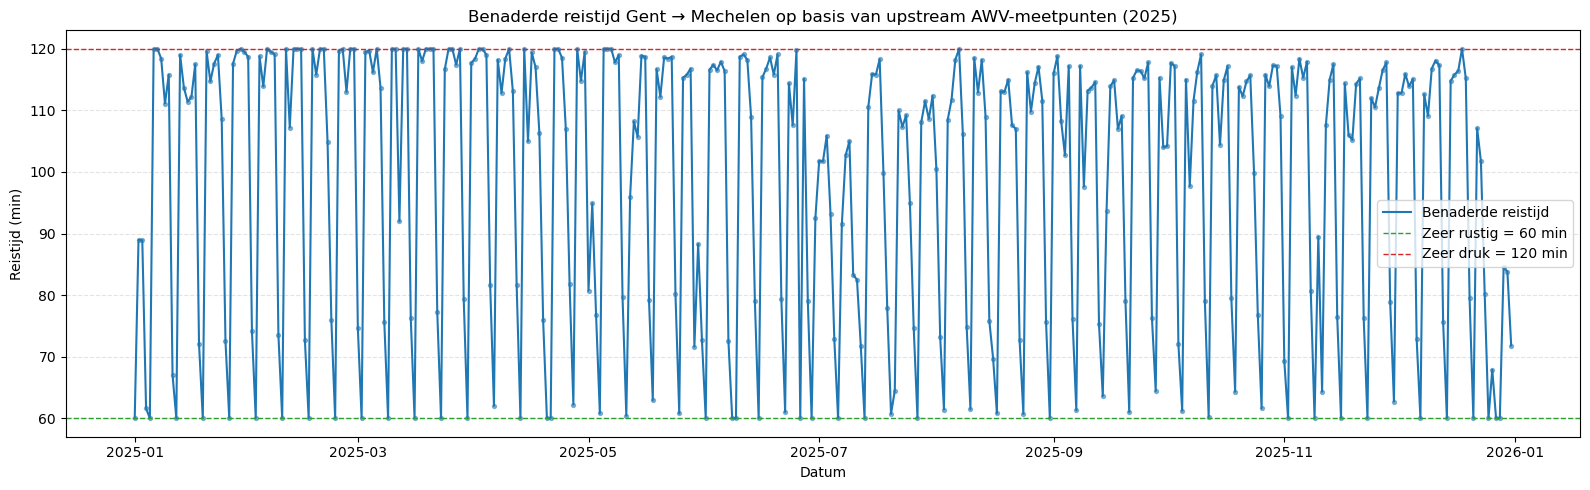

      date  car_actual_min   weekdag schoolvakantie brugdag
2025-01-01            60.0  woensdag             ja    neen
2025-01-02            89.0 donderdag             ja      ja
2025-01-03            88.9   vrijdag             ja    neen
2025-01-04            61.6  zaterdag             ja    neen
2025-01-05            60.0    zondag             ja    neen

✅ CSV opgeslagen als gent_mechelen_benadering_2025.csv
   Rijen: 365
   Min/Max reistijd: 60.0 / 120.0 min
   Drukteproxy: aanvraag-63... + aanvraag-a8... (904548 + 904834)
   Upstream meetpunten: 904548 (Neel Dofflaan 50), 904834 (Nederlandstraat 5)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SOURCE_CSV = "reistijd_gent_mechelen_2025.csv"
AWV_CSV = "E17_AWV_kwartierdata_2025.csv"
UPSTREAM_WORKBOOKS = [
    "aanvraag-63daf23b-bab3-4205-8fdf-120db78d1f47.xlsx",
    "aanvraag-a8b8d065-99a7-47e5-b7df-d241ae414897.xlsx",
]
UPSTREAM_MEETPUNTEN = [904548, 904834]
UPSTREAM_MEETPUNT_NAMEN = {
    904548: "Neel Dofflaan 50",
    904834: "Nederlandstraat 5",
}
WERKVENSTER_START = 7.0
WERKVENSTER_EIND = 8.5


def parse_excel_datetime(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_datetime(series, unit="D", origin="1899-12-30", errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def laad_upstream_proxy(workbooks: list[str], meetpunten: list[int]) -> pd.DataFrame:
    frames = []
    for workbook in workbooks:
        path = Path(workbook)
        if not path.exists():
            continue
        for meetpunt in meetpunten:
            try:
                sheet = pd.read_excel(path, sheet_name=str(meetpunt), engine="openpyxl")
            except Exception:
                continue

            benodigde = {"Start", "Eind", "Lichte voertuigen", "Zware voertuigen"}
            if not benodigde.issubset(set(sheet.columns)):
                continue

            sheet = sheet.rename(
                columns={
                    "Start": "start",
                    "Eind": "eind",
                    "Lichte voertuigen": "lichte_voertuigen",
                    "Zware voertuigen": "zware_voertuigen",
                }
            )
            sheet["start"] = parse_excel_datetime(sheet["start"])
            sheet["eind"] = parse_excel_datetime(sheet["eind"])
            sheet["meetpunt"] = int(meetpunt)
            sheet["bronbestand"] = path.name
            sheet["lichte_voertuigen"] = pd.to_numeric(sheet["lichte_voertuigen"], errors="coerce").fillna(0)
            sheet["zware_voertuigen"] = pd.to_numeric(sheet["zware_voertuigen"], errors="coerce").fillna(0)
            sheet["totaal"] = sheet["lichte_voertuigen"] + sheet["zware_voertuigen"]
            frames.append(
                sheet[[
                    "start",
                    "eind",
                    "meetpunt",
                    "totaal",
                    "lichte_voertuigen",
                    "zware_voertuigen",
                    "bronbestand",
                ]]
            )

    if not frames:
        return pd.DataFrame()

    raw = pd.concat(frames, ignore_index=True).dropna(subset=["start"])
    raw["datum"] = raw["start"].dt.normalize()
    raw["uur"] = raw["start"].dt.hour + raw["start"].dt.minute / 60

    dag_per_meetpunt = (
        raw[(raw["uur"] >= WERKVENSTER_START) & (raw["uur"] < WERKVENSTER_EIND)]
        .groupby(["datum", "meetpunt"], as_index=False)
        .agg(
            voertuigen=("totaal", "sum"),
            lichte_voertuigen=("lichte_voertuigen", "sum"),
            zware_voertuigen=("zware_voertuigen", "sum"),
        )
    )

    proxy = (
        dag_per_meetpunt.groupby("datum", as_index=False)
        .agg(
            awv_drukte_voertuigen=("voertuigen", "mean"),
            awv_drukte_lichte=("lichte_voertuigen", "mean"),
            awv_drukte_zware=("zware_voertuigen", "mean"),
            meetpunten_beschikbaar=("meetpunt", "nunique"),
        )
        .sort_values("datum")
    )
    return proxy


if not Path(SOURCE_CSV).exists():
    raise FileNotFoundError(f"{SOURCE_CSV} niet gevonden in de workspace.")

df_src = pd.read_csv(SOURCE_CSV, sep=";")
df_src["datum"] = pd.to_datetime(df_src["datum"], errors="coerce")

awv_proxy = laad_upstream_proxy(UPSTREAM_WORKBOOKS, UPSTREAM_MEETPUNTEN)

if awv_proxy.empty and Path(AWV_CSV).exists():
    awv = pd.read_csv(AWV_CSV, sep=";")
    awv["start"] = pd.to_datetime(awv["start"], errors="coerce")
    awv["datum"] = awv["start"].dt.normalize()
    awv["uur"] = awv["start"].dt.hour + awv["start"].dt.minute / 60
    awv["meetpunt"] = pd.to_numeric(awv["meetpunt"], errors="coerce")
    awv_proxy = (
        awv[(awv["meetpunt"] == 905109) & (awv["uur"] >= WERKVENSTER_START) & (awv["uur"] < WERKVENSTER_EIND)]
        .groupby("datum", as_index=False)["totaal"]
        .sum()
        .rename(columns={"totaal": "awv_drukte_voertuigen"})
    )
    awv_proxy["awv_drukte_lichte"] = pd.NA
    awv_proxy["awv_drukte_zware"] = pd.NA
    awv_proxy["meetpunten_beschikbaar"] = 1
    awv_proxy["drukte_bron"] = "E17_AWV_kwartierdata_2025.csv (905109)"
else:
    if not awv_proxy.empty:
        awv_proxy["drukte_bron"] = "aanvraag-63... + aanvraag-a8... (904548 + 904834)"

if awv_proxy.empty:
    raise ValueError("Geen bruikbare AWV-data gevonden voor de upstream meetpunten.")

df_src = df_src.merge(awv_proxy, on="datum", how="left")
if "tunnel_vc" in df_src.columns:
    df_src["drukte_proxy_voertuigen"] = df_src["awv_drukte_voertuigen"].combine_first(df_src["tunnel_vc"])
else:
    df_src["drukte_proxy_voertuigen"] = df_src["awv_drukte_voertuigen"]

if df_src["drukte_proxy_voertuigen"].isna().any():
    df_src["drukte_proxy_voertuigen"] = df_src["drukte_proxy_voertuigen"].fillna(df_src["drukte_proxy_voertuigen"].median())

pressure = df_src["drukte_proxy_voertuigen"].copy()
if pressure.notna().sum() == 0:
    raise ValueError("Geen bruikbare druktewaarden gevonden om de reistijd te schatten.")

quiet_ref = pressure.quantile(0.10)
busy_ref = pressure.quantile(0.90)
if pd.isna(quiet_ref) or pd.isna(busy_ref) or busy_ref <= quiet_ref:
    quiet_ref = pressure.min()
    busy_ref = pressure.max()

pressure_scaled = ((pressure - quiet_ref) / (busy_ref - quiet_ref)).clip(0, 1)
df_src["car_actual_min"] = (60 + pressure_scaled * 60).round(1)

# Labels om duidelijk te zien welke dagtypes je hebt.
df_src["weekdag_naam"] = df_src.get("weekdag_naam", df_src["datum"].dt.day_name())
df_src["schoolvakantie"] = df_src.get("schoolvakantie", False)
if df_src["schoolvakantie"].dtype != bool:
    df_src["schoolvakantie"] = df_src["schoolvakantie"].astype(str).str.lower().isin(["true", "1", "ja", "yes"])

# Belgische feestdagen 2025 om brugdagen te kunnen afleiden.
FEESTDAGEN_2025 = pd.to_datetime([
    "2025-01-01", "2025-04-21", "2025-05-01", "2025-05-29", "2025-06-09",
    "2025-07-21", "2025-08-15", "2025-11-01", "2025-11-11", "2025-12-25",
])
feestdagen_set = set(FEESTDAGEN_2025.date)

dates = df_src["datum"].dt.date
df_src["feestdag"] = dates.isin(feestdagen_set)

# Brugdag = werkdag die aansluit op een feestdag of een weekend, maar zelf geen feestdag is.
weekday_nr = df_src["datum"].dt.weekday
is_werkdag = weekday_nr < 5
vorige_dag_feestdag = (df_src["datum"] - pd.Timedelta(days=1)).dt.date.isin(feestdagen_set)
volgende_dag_feestdag = (df_src["datum"] + pd.Timedelta(days=1)).dt.date.isin(feestdagen_set)

df_src["brugdag"] = (
    (~df_src["feestdag"]) &
    is_werkdag &
    (
        vorige_dag_feestdag |
        volgende_dag_feestdag |
        ((weekday_nr == 5) & vorige_dag_feestdag) |
        ((weekday_nr == 0) & volgende_dag_feestdag)
    )
)

# Grafiek: dagelijkse schatting tussen 60 en 120 minuten.
plot_df = df_src[["datum", "weekdag_naam", "schoolvakantie", "brugdag", "car_actual_min"]].copy().sort_values("datum")
plot_df["dagtype"] = pd.Series("schooldag", index=plot_df.index)
plot_df.loc[plot_df["schoolvakantie"], "dagtype"] = "schoolvakantie"
plot_df.loc[plot_df["brugdag"], "dagtype"] = "brugdag"

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(plot_df["datum"], plot_df["car_actual_min"], color="#1f77b4", linewidth=1.5, label="Benaderde reistijd")
ax.scatter(plot_df["datum"], plot_df["car_actual_min"], s=8, color="#1f77b4", alpha=0.5)
ax.axhline(60, color="#2ca02c", linestyle="--", linewidth=1, label="Zeer rustig = 60 min")
ax.axhline(120, color="#d62728", linestyle="--", linewidth=1, label="Zeer druk = 120 min")
ax.set_title("Benaderde reistijd Gent → Mechelen op basis van upstream AWV-meetpunten (2025)")
ax.set_xlabel("Datum")
ax.set_ylabel("Reistijd (min)")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()

# Interactieve versie met diepere zoom + markering van dagtypes.
try:
    import plotly.express as px
    import plotly.graph_objects as go

    plotly_fig = px.scatter(
        plot_df,
        x="datum",
        y="car_actual_min",
        color="dagtype",
        color_discrete_map={
            "schooldag": "#1f77b4",
            "brugdag": "#ff7f0e",
            "schoolvakantie": "#2ca02c",
        },
        title="Benaderde reistijd Gent → Mechelen op basis van upstream AWV-meetpunten (interactief)",
        labels={"datum": "Datum", "car_actual_min": "Reistijd (min)", "dagtype": "Dagtype"},
        hover_data={
            "datum": "|%d-%m-%Y",
            "weekdag_naam": True,
            "schoolvakantie": True,
            "brugdag": True,
            "car_actual_min": ":.1f",
        },
    )
    plotly_fig.add_trace(
        go.Scatter(
            x=plot_df["datum"],
            y=plot_df["car_actual_min"],
            mode="lines",
            name="Trend",
            line=dict(color="#111111", width=1.4),
            hoverinfo="skip",
        )
    )
    for start, end, label, fillcolor in [
        ("2025-01-01", "2025-01-05", "Kerstvakantie", "rgba(44,160,44,0.10)"),
        ("2025-03-03", "2025-03-09", "Krokusvakantie", "rgba(44,160,44,0.10)"),
        ("2025-04-07", "2025-04-21", "Paasvakantie", "rgba(44,160,44,0.10)"),
        ("2025-07-01", "2025-08-31", "Zomervakantie", "rgba(44,160,44,0.10)"),
        ("2025-10-27", "2025-11-02", "Herfstvakantie", "rgba(44,160,44,0.10)"),
        ("2025-12-22", "2025-12-31", "Kerstvakantie", "rgba(44,160,44,0.10)"),
    ]:
        plotly_fig.add_vrect(x0=start, x1=end, fillcolor=fillcolor, opacity=0.2, line_width=0, layer="below")

    plotly_fig.update_traces(marker=dict(size=5))
    plotly_fig.update_layout(
        template="plotly_white",
        height=560,
        dragmode="zoom",
        hovermode="x unified",
        xaxis=dict(
            type="date",
            tickformat="%d-%m-%Y",
            tickangle=-45,
            rangeslider=dict(visible=True, thickness=0.08),
        ),
    )
    plotly_fig.show(config={"scrollZoom": True, "displaylogo": False})

    # Extra detailgrafiek: weekdagen vergelijken op twee niveaus.
    weekday_order = ["maandag", "dinsdag", "woensdag", "donderdag", "vrijdag", "zaterdag", "zondag"]
    weekday_map = {0: "maandag", 1: "dinsdag", 2: "woensdag", 3: "donderdag", 4: "vrijdag", 5: "zaterdag", 6: "zondag"}
    plot_df["weekday"] = plot_df["datum"].dt.weekday.map(weekday_map)

    normal_schooldays = plot_df[(~plot_df["schoolvakantie"]) & (~plot_df["brugdag"]) & (plot_df["datum"].dt.weekday < 5)]
    all_workdays = plot_df[(plot_df["datum"].dt.weekday < 5)]

    compare_rows = []
    for label, frame in [
        ("alle werkdagen", all_workdays),
        ("normale schooldagen", normal_schooldays),
    ]:
        grouped = frame.groupby("weekday", as_index=False)["car_actual_min"].mean()
        grouped["weekday"] = pd.Categorical(grouped["weekday"], categories=weekday_order, ordered=True)
        grouped = grouped.sort_values("weekday")
        grouped["scenario"] = label
        compare_rows.append(grouped)
    compare_df = pd.concat(compare_rows, ignore_index=True)

    weekday_fig = px.bar(
        compare_df,
        x="weekday",
        y="car_actual_min",
        color="scenario",
        barmode="group",
        title="Gemiddelde benaderde reistijd per weekdag (2025)",
        labels={"weekday": "Weekdag", "car_actual_min": "Reistijd (min)", "scenario": "Selectie"},
        color_discrete_map={
            "alle werkdagen": "#6baed6",
            "normale schooldagen": "#08519c",
        },
    )
    weekday_fig.update_layout(template="plotly_white", height=430)
    weekday_fig.show(config={"scrollZoom": True, "displaylogo": False})

    # Boxplot voor normale schooldagen om te zien dat woensdag niet per se de rustigste is.
    box_data = plot_df[(plot_df["datum"].dt.weekday < 5) & (~plot_df["schoolvakantie"]) & (~plot_df["brugdag"])].copy()
    box_fig = px.box(
        box_data,
        x="weekday",
        y="car_actual_min",
        category_orders={"weekday": weekday_order[:5]},
        title="Verdeling reistijd per weekdag op normale schooldagen (zonder vakanties en brugdagen)",
        labels={"weekday": "Weekdag", "car_actual_min": "Reistijd (min)"},
        points="all",
    )
    box_fig.update_layout(template="plotly_white", height=460)
    box_fig.show(config={"scrollZoom": True, "displaylogo": False})
except Exception as exc:
    print(f"⚠️  Interactieve Plotly-zoom kon niet worden geladen: {exc}")

# CSV-export in de gevraagde vorm, uitgebreid met daginformatie.
export_df = plot_df[["datum", "car_actual_min", "weekdag_naam", "schoolvakantie", "brugdag"]].copy()
export_df["date"] = export_df["datum"].dt.strftime("%Y-%m-%d")
export_df["schoolvakantie"] = export_df["schoolvakantie"].map({True: "ja", False: "neen"})
export_df["brugdag"] = export_df["brugdag"].map({True: "ja", False: "neen"})
export_df["weekdag"] = export_df["weekdag_naam"]
export_df = export_df[["date", "car_actual_min", "weekdag", "schoolvakantie", "brugdag"]]
CSV_BESTAND = "gent_mechelen_benadering_2025.csv"
export_df.to_csv(CSV_BESTAND, index=False)

print(export_df.head().to_string(index=False))
print(f"\n✅ CSV opgeslagen als {CSV_BESTAND}")
print(f"   Rijen: {len(export_df)}")
print(f"   Min/Max reistijd: {export_df['car_actual_min'].min():.1f} / {export_df['car_actual_min'].max():.1f} min")
print(f"   Drukteproxy: {awv_proxy['drukte_bron'].iloc[0]}")
print(f"   Upstream meetpunten: {', '.join(f'{mp} ({UPSTREAM_MEETPUNT_NAMEN[mp]})' for mp in UPSTREAM_MEETPUNTEN)}")

In [2]:
import xml.etree.ElementTree as ET
from pathlib import Path

MIV_CONFIG = Path("miv_config.xml")
if not MIV_CONFIG.exists():
    raise FileNotFoundError("miv_config.xml niet gevonden in de workspace.")

def laad_miv_config(pad: Path) -> pd.DataFrame:
    root = ET.parse(pad).getroot()
    rijen = []
    for mp in root.findall("meetpunt"):
        def f(tag):
            waarde = mp.findtext(tag)
            return waarde.replace(",", ".") if waarde else waarde
        def naar_float(waarde):
            try:
                return float(waarde)
            except (TypeError, ValueError):
                return None
        rijen.append({
            "lve_nr": int(mp.findtext("lve_nr", "0")),
            "naam": mp.findtext("volledige_naam"),
            "ident_8": mp.findtext("Ident_8"),
            "beschrijvende_id": mp.findtext("beschrijvende_id"),
            "kmpt": f("Kmp_Rsys"),
            "rijstrook": mp.findtext("Rijstrook"),
            "lat": naar_float(f("breedtegraad_EPSG_4326")),
            "lon": naar_float(f("lengtegraad_EPSG_4326")),
        })
    return pd.DataFrame(rijen)

cfg = laad_miv_config(MIV_CONFIG)
tunnel = cfg[cfg["naam"].str.contains("Kennedy snede", na=False)].copy()

tunnel_punten = (
    tunnel.groupby(["lve_nr", "naam", "ident_8"], as_index=False)
    .agg(rijstroken=("rijstrook", "nunique"),
         kmpt=("kmpt", "first"),
         lat=("lat", "mean"),
         lon=("lon", "mean"))
    .sort_values("kmpt")
)

print("🚇 Kennedytunnel-meetpunten uit miv_config.xml")
display(tunnel_punten)
print("\nDeze punten zijn live meetpunten op de tunnel/R1. Ze dienen als calibration points,")
print("maar er is geen historische 2025-export voor deze lve_nrs in de workspace.")

verkeersdata = Path("verkeersdata.xml")
if verkeersdata.exists():
    print("\nverkeersdata.xml is aanwezig voor een live snapshot-check, maar niet als historisch bestand.")
    print("Gebruik die snapshot enkel om te zien of de tunnel op dit moment vertraagd of file-achtig is.")

🚇 Kennedytunnel-meetpunten uit miv_config.xml


,lve_nr,naam,ident_8,rijstroken,kmpt,lat,lon
10,693,"Kennedy snede kmpt 14,00",R0010001,3,0.014,51.206385,4.370792
11,693,"Kennedy snede kmpt 14,00",R0010002,3,0.014,51.206277,4.370560
6,691,"Kennedy snede kmpt 13,59",R0010001,3,13.593,51.203535,4.373810
7,691,"Kennedy snede kmpt 13,59",R0010002,3,13.593,51.203413,4.373600
0,527,Kennedy snede 1,R0010001,6,13.715,51.204358,4.372778
1,527,Kennedy snede 1,R0010002,6,13.716,51.204358,4.372778
8,692,"Kennedy snede kmpt 13,79",R0010001,3,13.792,51.204998,4.372259
9,692,"Kennedy snede kmpt 13,79",R0010002,3,13.793,51.204884,4.372036
2,528,Kennedy snede 2,R0010001,6,13.914,51.205841,4.371200
3,528,Kennedy snede 2,R0010002,6,13.915,51.205841,4.371200



Deze punten zijn live meetpunten op de tunnel/R1. Ze dienen als calibration points,
maar er is geen historische 2025-export voor deze lve_nrs in de workspace.

verkeersdata.xml is aanwezig voor een live snapshot-check, maar niet als historisch bestand.
Gebruik die snapshot enkel om te zien of de tunnel op dit moment vertraagd of file-achtig is.


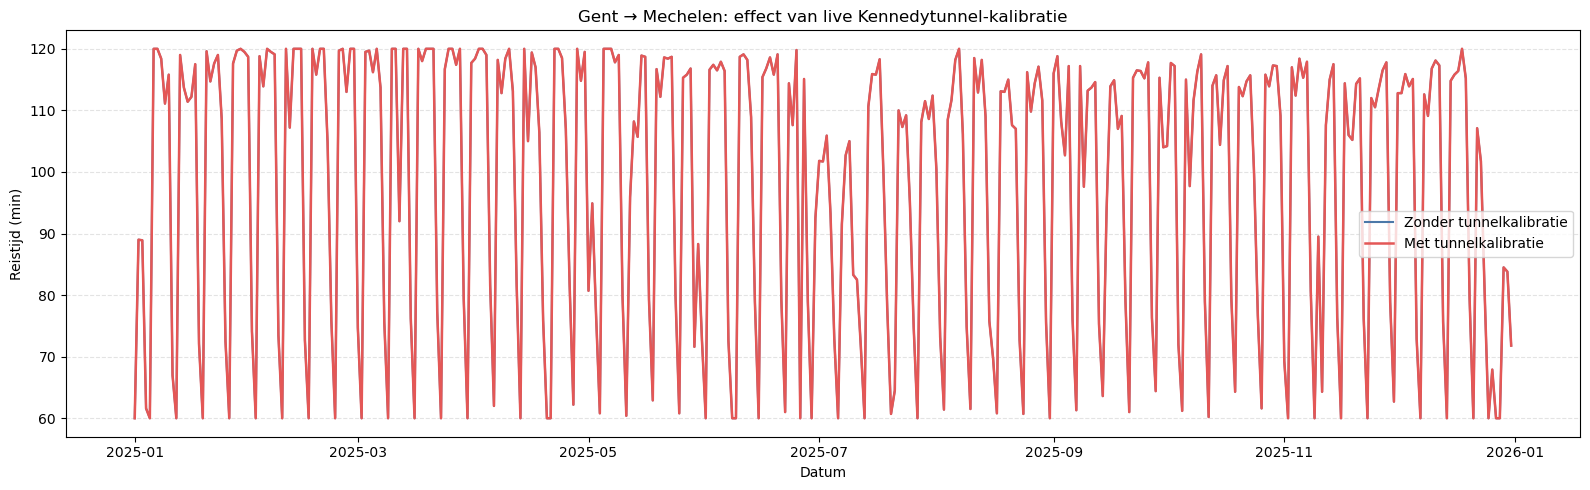

📡 Tunnel snapshot publicatie: onbekend
   Kalibratiebron: bezettingsgraad
   Gem. bezettingsgraad tunnelpunten: 3.4%
   Slowdown-factor: 0.000

✅ Export met tunnelkalibratie: gent_mechelen_benadering_2025_tunnelkalibratie.csv
   Gem. reistijd zonder/ met kalibratie: 98.7 / 98.7 min


In [5]:
import xml.etree.ElementTree as ET
import numpy as np

VERKEERSDATA_XML = Path("verkeersdata.xml")
if not VERKEERSDATA_XML.exists():
    raise FileNotFoundError("verkeersdata.xml niet gevonden in de workspace.")


def local_name(tag: str) -> str:
    return tag.split("}", 1)[-1] if "}" in tag else tag


def child_text(parent: ET.Element, child_local_tag: str, default: str | None = None) -> str | None:
    for child in list(parent):
        if local_name(child.tag) == child_local_tag:
            return child.text
    return default


def parse_tunnel_snapshot(xml_pad: Path, tunnel_lves: list[int]) -> pd.DataFrame:
    root = ET.parse(xml_pad).getroot()
    records = []
    tijd_pub = root.attrib.get("tijd_publicatie")

    for mp in root.iter():
        if local_name(mp.tag) != "meetpunt":
            continue

        lve_text = child_text(mp, "lve_nr", "0")
        try:
            lve = int(lve_text)
        except (TypeError, ValueError):
            continue

        if lve not in tunnel_lves:
            continue

        bez = np.nan
        for child in list(mp):
            if local_name(child.tag) == "rekendata":
                bez_text = child_text(child, "bezettingsgraad", None)
                try:
                    bez = float(bez_text) if bez_text is not None else np.nan
                except (TypeError, ValueError):
                    bez = np.nan

        for md in list(mp):
            if local_name(md.tag) != "meetdata":
                continue
            if md.attrib.get("klasse_id") != "1":
                continue

            snel_text = child_text(md, "voertuigsnelheid_harmonisch", "0")
            inten_text = child_text(md, "verkeersintensiteit", "0")

            try:
                snel = float(snel_text)
            except (TypeError, ValueError):
                snel = np.nan
            try:
                inten = int(float(inten_text))
            except (TypeError, ValueError):
                inten = 0

            if snel >= 252:
                snel = np.nan

            records.append(
                {
                    "tijd_publicatie": tijd_pub,
                    "lve_nr": lve,
                    "snelheid_harm_kmh": snel,
                    "intensiteit_per_min": inten,
                    "bezettingsgraad": bez,
                }
            )

    return pd.DataFrame(records)


# 1) Live tunnelsnapshot ophalen
unieke_tunnel_lves = sorted(tunnel_punten["lve_nr"].dropna().astype(int).unique().tolist())
tunnel_snap = parse_tunnel_snapshot(VERKEERSDATA_XML, unieke_tunnel_lves)
if tunnel_snap.empty:
    raise ValueError("Geen tunnelmetingen gevonden in verkeersdata.xml voor de Kennedy-lve_nrs.")

vrije_snelheid = 100.0
snap_valid = tunnel_snap[(tunnel_snap["snelheid_harm_kmh"].notna()) & (tunnel_snap["snelheid_harm_kmh"] > 0)].copy()

if not snap_valid.empty:
    gewicht = snap_valid["intensiteit_per_min"].clip(lower=1)
    gewogen_snelheid = (snap_valid["snelheid_harm_kmh"] * gewicht).sum() / gewicht.sum()
    slowdown = float(np.clip((vrije_snelheid - gewogen_snelheid) / vrije_snelheid, 0.0, 0.4))
    calibratie_bron = "snelheid"
else:
    bez_mean = tunnel_snap["bezettingsgraad"].dropna().mean()
    gewogen_snelheid = np.nan
    if pd.isna(bez_mean):
        slowdown = 0.0
        calibratie_bron = "geen geldige tunnelmeting"
    else:
        slowdown = float(np.clip((bez_mean - 15.0) / 50.0, 0.0, 0.35))
        calibratie_bron = "bezettingsgraad"

# 2) Dagelijkse trajecttijd bijsturen met tunnelcorrectie
if "drukte_proxy_voertuigen" not in df_src.columns:
    raise ValueError("drukte_proxy_voertuigen ontbreekt. Voer eerst cel 45 uit.")

p10 = df_src["drukte_proxy_voertuigen"].quantile(0.10)
p90 = df_src["drukte_proxy_voertuigen"].quantile(0.90)
if pd.isna(p10) or pd.isna(p90) or p90 <= p10:
    drukte_norm = pd.Series(0.5, index=df_src.index)
else:
    drukte_norm = ((df_src["drukte_proxy_voertuigen"] - p10) / (p90 - p10)).clip(0, 1)

extra_tunnel_min = slowdown * (6.0 + 14.0 * drukte_norm)
df_src["car_actual_tunnel_cal_min"] = (df_src["car_actual_min"] + extra_tunnel_min).round(1)

cal_export = df_src[["datum", "car_actual_min", "car_actual_tunnel_cal_min", "drukte_proxy_voertuigen"]].copy()
cal_export["date"] = cal_export["datum"].dt.strftime("%Y-%m-%d")
cal_export = cal_export[["date", "car_actual_min", "car_actual_tunnel_cal_min", "drukte_proxy_voertuigen"]]
CAL_CSV = "gent_mechelen_benadering_2025_tunnelkalibratie.csv"
cal_export.to_csv(CAL_CSV, index=False)

# 3) Vergelijkingsplot
plot_cmp = df_src[["datum", "car_actual_min", "car_actual_tunnel_cal_min"]].sort_values("datum")
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(plot_cmp["datum"], plot_cmp["car_actual_min"], label="Zonder tunnelkalibratie", linewidth=1.5, color="#4c78a8")
ax.plot(plot_cmp["datum"], plot_cmp["car_actual_tunnel_cal_min"], label="Met tunnelkalibratie", linewidth=1.8, color="#e45756")
ax.set_title("Gent → Mechelen: effect van live Kennedytunnel-kalibratie")
ax.set_xlabel("Datum")
ax.set_ylabel("Reistijd (min)")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()

pub = tunnel_snap["tijd_publicatie"].dropna().iloc[0] if tunnel_snap["tijd_publicatie"].notna().any() else "onbekend"
print(f"📡 Tunnel snapshot publicatie: {pub}")
print(f"   Kalibratiebron: {calibratie_bron}")
if calibratie_bron == "snelheid":
    print(f"   Gewogen tunnelsnelheid (personenwagens): {gewogen_snelheid:.1f} km/u")
else:
    bez_mean = tunnel_snap["bezettingsgraad"].dropna().mean()
    print(f"   Gem. bezettingsgraad tunnelpunten: {bez_mean:.1f}%")
print(f"   Slowdown-factor: {slowdown:.3f}")

print(f"\n✅ Export met tunnelkalibratie: {CAL_CSV}")
print(
    f"   Gem. reistijd zonder/ met kalibratie: "
    f"{df_src['car_actual_min'].mean():.1f} / {df_src['car_actual_tunnel_cal_min'].mean():.1f} min"
)

In [6]:
# Volledig overzicht: alle geschatte reistijden op basis van drukte
if "car_actual_min" not in df_src.columns:
    raise ValueError("car_actual_min ontbreekt. Voer eerst cel 45 uit.")

overzicht_kolommen = ["datum", "drukte_proxy_voertuigen", "car_actual_min"]
if "car_actual_tunnel_cal_min" in df_src.columns:
    overzicht_kolommen.append("car_actual_tunnel_cal_min")

overzicht = (
    df_src[overzicht_kolommen]
    .copy()
    .sort_values("datum")
    .rename(
        columns={
            "datum": "date",
            "drukte_proxy_voertuigen": "drukte_voertuigen",
            "car_actual_min": "geschatte_reistijd_min",
            "car_actual_tunnel_cal_min": "geschatte_reistijd_tunnelkalibratie_min",
        }
    )
)
overzicht["date"] = overzicht["date"].dt.strftime("%Y-%m-%d")

# Toon de volledige tabel in de output
print(overzicht.to_string(index=False))

# Extra export met dezelfde volledige tabel
OVERZICHT_CSV = "gent_mechelen_geschatte_reistijd_volledig.csv"
overzicht.to_csv(OVERZICHT_CSV, index=False)
print(f"\n✅ Volledig overzicht opgeslagen als {OVERZICHT_CSV}")
print(f"   Aantal dagen: {len(overzicht)}")

      date  drukte_voertuigen  geschatte_reistijd_min  geschatte_reistijd_tunnelkalibratie_min
2025-01-01              455.5                    60.0                                     60.0
2025-01-02             3768.0                    89.0                                     89.0
2025-01-03             3766.0                    88.9                                     88.9
2025-01-04             1651.0                    61.6                                     61.6
2025-01-05              777.5                    60.0                                     60.0
2025-01-06             6236.0                   120.0                                    120.0
2025-01-07             6240.5                   120.0                                    120.0
2025-01-08             6048.5                   118.4                                    118.4
2025-01-09             5481.5                   111.1                                    111.1
2025-01-10             5849.5                   11